# 기본 시도

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---------------------------------------------------
# 1) Random-effects meta-analysis
# ---------------------------------------------------
def meta_random_from_log(log_rr, se_log_rr):
    y = np.asarray(log_rr, dtype=float)
    se = np.asarray(se_log_rr, dtype=float)
    v = se**2

    k = len(y)
    if k == 0:
        return None

    w = 1.0 / v
    y_bar = np.sum(w * y) / np.sum(w)
    Q = np.sum(w * (y - y_bar)**2)
    df = k - 1

    tau2 = max(0, (Q - df) / (np.sum(w) - np.sum(w**2)/np.sum(w))) if k > 1 else 0
    w_re = 1.0 / (v + tau2)

    mu = np.sum(w_re * y) / np.sum(w_re)
    se_mu = np.sqrt(1.0 / np.sum(w_re))

    return {
        "k": k,
        "rr": np.exp(mu),
        "ci_low": np.exp(mu - 1.96 * se_mu),
        "ci_high": np.exp(mu + 1.96 * se_mu),
        "tau2": tau2
    }


# ---------------------------------------------------
# 2) 실제 파일 기준 컬럼 정규화
# ---------------------------------------------------
def normalize_cols(df):
    colmap = {}

    for c in df.columns:
        lc = c.lower()

        if lc in ["analysisid", "analysis_id"]:
            colmap[c] = "analysis_id"
        elif lc in ["targetid", "target_id"]:
            colmap[c] = "target_id"
        elif lc in ["comparatorid", "comparator_id"]:
            colmap[c] = "comparator_id"
        elif lc in ["outcomeid", "outcome_id"]:
            colmap[c] = "outcome_id"

        elif lc in ["logrr", "log_rr"]:
            colmap[c] = "log_rr"
        elif lc in ["selogrr", "se_log_rr"]:
            colmap[c] = "se_log_rr"

        elif lc in ["target_outcomes", "eventstarget"]:
            colmap[c] = "target_outcomes"
        elif lc in ["comparator_outcomes", "eventscomparator"]:
            colmap[c] = "comparator_outcomes"

    return df.rename(columns=colmap)


# ---------------------------------------------------
# 3) -5 사건수 치환
# ---------------------------------------------------
def replace_minus5(df_cm, df_as):
    if df_as is None:
        return df_cm

    df_cm = normalize_cols(df_cm)
    df_as = normalize_cols(df_as)

    df = df_cm.merge(
        df_as[[
            "analysis_id","target_id","comparator_id","outcome_id",
            "target_outcomes","comparator_outcomes"
        ]],
        on=["analysis_id","target_id","comparator_id","outcome_id"],
        how="left",
        suffixes=("","_as")
    )

    m = (df["target_outcomes"] == -5) & df["target_outcomes_as"].notna()
    df.loc[m, "target_outcomes"] = df.loc[m, "target_outcomes_as"]

    m = (df["comparator_outcomes"] == -5) & df["comparator_outcomes_as"].notna()
    df.loc[m, "comparator_outcomes"] = df.loc[m, "comparator_outcomes_as"]

    return df.drop(columns=[c for c in df.columns if c.endswith("_as")])


# ---------------------------------------------------
# 4) 경로
# ---------------------------------------------------
base_path = "/content/drive/MyDrive/파이썬 실행 위한 데이터/0114/escitalopram vs trazodone_0114"
analysis_id = 1   # KWMC 예시는 analysis_id = 1

summary_records = []


# ---------------------------------------------------
# 5) outcome별 처리
# ---------------------------------------------------
for outcome_name in os.listdir(base_path):
    folder = os.path.join(base_path, outcome_name)
    if not os.path.isdir(folder):
        continue

    cm_files = glob.glob(os.path.join(folder, "*cohort_method_result.csv"))
    as_folder = os.path.join(folder, "analysisSummary")

    for cm_fp in cm_files:
        dbid = os.path.basename(cm_fp).split("_")[0]

        df_cm = normalize_cols(pd.read_csv(cm_fp))
        df_cm = df_cm[df_cm["analysis_id"] == analysis_id].copy()
        if df_cm.empty:
            continue

        # outcome_id 최소값 1개
        min_outcome = (
            df_cm.groupby(["target_id","comparator_id"])["outcome_id"]
            .min().reset_index()
        )
        df_cm = df_cm.merge(min_outcome, on=["target_id","comparator_id","outcome_id"])

        # analysisSummary
        as_fp = os.path.join(as_folder, f"{dbid}_analysisSummary.csv")
        df_as = normalize_cols(pd.read_csv(as_fp)) if os.path.isfile(as_fp) else None
        if df_as is not None:
            df_as = df_as[df_as["analysis_id"] == analysis_id]

        df_cm = replace_minus5(df_cm, df_as)

        # 메타분석
        for (t,c,o), g in df_cm.groupby(["target_id","comparator_id","outcome_id"]):
            g = g.dropna(subset=["log_rr","se_log_rr"])
            if g.empty:
                continue

            res = meta_random_from_log(g["log_rr"], g["se_log_rr"])
            if res is None:
                continue

            summary_records.append({
                "outcome": outcome_name,
                "target_id": t,
                "comparator_id": c,
                "outcome_id": o,
                "k": res["k"],
                "rr_random": res["rr"],
                "ci_low": res["ci_low"],
                "ci_high": res["ci_high"],
            })


summary_df = pd.DataFrame(summary_records)
summary_df


,outcome,target_id,comparator_id,outcome_id,k,rr_random,ci_low,ci_high
0,Cardiac arrest,1352,1369,1198,1,1.166667e+00,3.815341e-01,3.567469e+00
1,Atrial fibrillation,1353,1370,1316,1,2.000000e+00,1.334951e-01,2.996366e+01
2,Atrial fibrillation,1353,1370,1316,1,1.321217e-09,9.478641e-24,1.841628e+05
3,blood side effects,1354,1372,1199,1,2.500000e-01,2.174792e-02,2.873838e+00
4,blood side effects,1354,1372,1199,1,5.000000e-01,3.337377e-02,7.490914e+00
5,blood side effects,1354,1372,1199,1,1.500000e+00,4.054068e-01,5.549981e+00
6,blood side effects,1354,1372,1199,1,1.666667e+00,8.083662e-01,3.436286e+00
7,blood side effects,1354,1372,1199,1,8.333333e-01,2.455162e-01,2.828508e+00
8,blood side effects,1354,1372,1199,1,2.000000e-01,1.835144e-02,2.179665e+00
9,circulatory system,1305,1374,1205,1,3.000000e+00,2.388314e-01,3.768349e+01


# analysis id 반영(다음에는 이거부터 복붙12분이상걸림)_summary df 생성

In [ ]:
# ---------------------------------------------------
# 0) analysis_id 매핑 엑셀 읽기
# ---------------------------------------------------
# 엑셀 파일을 MyDrive 안 적당한 곳에 두고 경로만 맞춰줘.
# 예시) /content/drive/MyDrive/파이썬 실행 위한 데이터/1215/48 analysisId 항목.xlsx
analysis_map_path = "/content/drive/MyDrive/파이썬 실행 위한 데이터/18 analysisId 항목_0114.xlsx"

analysis_map_df = pd.read_excel(analysis_map_path)

# 컬럼명 자동 탐색(엑셀 컬럼명이 약간 달라도 동작하도록)
cols_lower = {c: c.lower() for c in analysis_map_df.columns}
id_col = None
label_col = None

for c, lc in cols_lower.items():
    if lc in ["analysis_id", "analysisid", "analysis id", "analysisid 번호", "analysis id 번호", "id"]:
        id_col = c
        break

# 라벨 컬럼은 id_col 제외한 나머지에서 가장 그럴듯한 텍스트 컬럼 하나를 잡음
candidate_label_cols = [c for c in analysis_map_df.columns if c != id_col]
if len(candidate_label_cols) == 1:
    label_col = candidate_label_cols[0]
else:
    # 흔한 이름 우선
    for c in candidate_label_cols:
        lc = c.lower()
        if lc in ["label", "name", "analysis_name", "analysis", "설정", "설정값", "항목", "description", "desc"]:
            label_col = c
            break
    if label_col is None:
        label_col = candidate_label_cols[0]

analysis_map_df = analysis_map_df[[id_col, label_col]].dropna()
analysis_map_df[id_col] = analysis_map_df[id_col].astype(int)

analysis_id_to_label = dict(zip(analysis_map_df[id_col], analysis_map_df[label_col].astype(str)))

# 분석할 analysis_id 목록 (엑셀에 있는 것 전체를 기본으로)
analysis_ids_to_run = sorted(analysis_id_to_label.keys())


# ---------------------------------------------------
# 1) Random-effects meta-analysis
# ---------------------------------------------------
def meta_random_from_log(log_rr, se_log_rr):
    y = np.asarray(log_rr, dtype=float)
    se = np.asarray(se_log_rr, dtype=float)
    v = se**2

    k = len(y)
    if k == 0:
        return None

    w = 1.0 / v
    y_bar = np.sum(w * y) / np.sum(w)
    Q = np.sum(w * (y - y_bar)**2)
    df = k - 1

    if k <= 1:
        tau2 = 0.0
    else:
        denom = np.sum(w) - np.sum(w**2)/np.sum(w)
        tau2 = max(0.0, (Q - df) / denom) if denom > 0 else 0.0

    w_re = 1.0 / (v + tau2)
    mu = np.sum(w_re * y) / np.sum(w_re)
    se_mu = np.sqrt(1.0 / np.sum(w_re))

    return {
        "k": k,
        "rr": np.exp(mu),
        "ci_low": np.exp(mu - 1.96 * se_mu),
        "ci_high": np.exp(mu + 1.96 * se_mu),
        "tau2": tau2
    }


# ---------------------------------------------------
# 2) 컬럼명 정규화 (KWMC 예시 구조 기준)
# ---------------------------------------------------
def normalize_cols(df):
    colmap = {}
    for c in df.columns:
        lc = c.lower()

        if lc in ["analysisid", "analysis_id"]:
            colmap[c] = "analysis_id"
        elif lc in ["targetid", "target_id"]:
            colmap[c] = "target_id"
        elif lc in ["comparatorid", "comparator_id"]:
            colmap[c] = "comparator_id"
        elif lc in ["outcomeid", "outcome_id"]:
            colmap[c] = "outcome_id"

        elif lc in ["logrr", "log_rr", "logrr.1"]:
            colmap[c] = "log_rr"
        elif lc in ["selogrr", "se_log_rr", "selogrr.1"]:
            colmap[c] = "se_log_rr"

        # cohort_method_result 사건수: target_outcomes / comparator_outcomes
        elif lc in ["target_outcomes", "targetoutcomes"]:
            colmap[c] = "target_outcomes"
        elif lc in ["comparator_outcomes", "comparatoroutcomes"]:
            colmap[c] = "comparator_outcomes"

        # analysisSummary 사건수: eventsTarget / eventsComparator
        elif lc in ["eventstarget"]:
            colmap[c] = "target_outcomes"
        elif lc in ["eventscomparator"]:
            colmap[c] = "comparator_outcomes"

    return df.rename(columns=colmap)


def get_dbid_from_filename(fp):
    return os.path.basename(fp).split("_")[0]


# ---------------------------------------------------
# 3) -5 사건수 치환 (target_outcomes / comparator_outcomes)
# ---------------------------------------------------
def replace_minus5_counts(df_cm, df_as):
    if df_as is None or df_as.empty:
        return df_cm

    df_cm = normalize_cols(df_cm).copy()
    df_as = normalize_cols(df_as).copy()

    need = {"analysis_id","target_id","comparator_id","outcome_id","target_outcomes","comparator_outcomes"}
    if not {"analysis_id","target_id","comparator_id","outcome_id"}.issubset(df_as.columns):
        return df_cm
    if ("target_outcomes" not in df_as.columns) and ("comparator_outcomes" not in df_as.columns):
        return df_cm

    keep_cols = ["analysis_id","target_id","comparator_id","outcome_id"]
    if "target_outcomes" in df_as.columns:
        keep_cols.append("target_outcomes")
    if "comparator_outcomes" in df_as.columns:
        keep_cols.append("comparator_outcomes")

    df_m = df_cm.merge(
        df_as[keep_cols].drop_duplicates(),
        on=["analysis_id","target_id","comparator_id","outcome_id"],
        how="left",
        suffixes=("", "_as")
    )

    if "target_outcomes" in df_m.columns and "target_outcomes_as" in df_m.columns:
        m = (df_m["target_outcomes"] == -5) & df_m["target_outcomes_as"].notna()
        df_m.loc[m, "target_outcomes"] = df_m.loc[m, "target_outcomes_as"]

    if "comparator_outcomes" in df_m.columns and "comparator_outcomes_as" in df_m.columns:
        m = (df_m["comparator_outcomes"] == -5) & df_m["comparator_outcomes_as"].notna()
        df_m.loc[m, "comparator_outcomes"] = df_m.loc[m, "comparator_outcomes_as"]

    drop_cols = [c for c in df_m.columns if c.endswith("_as")]
    return df_m.drop(columns=drop_cols)


# ---------------------------------------------------
# 4) 경로:
# ---------------------------------------------------
base_path = "/content/drive/MyDrive/파이썬 실행 위한 데이터/0114/escitalopram vs trazodone_0114"


# ---------------------------------------------------
# 5) outcome별 + analysis_id별 메타분석
# ---------------------------------------------------
summary_records = []

outcome_folders = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])

for outcome_name in outcome_folders:
    folder = os.path.join(base_path, outcome_name)
    cm_files = glob.glob(os.path.join(folder, "*cohort_method_result.csv"))
    as_folder = os.path.join(folder, "analysisSummary")

    if len(cm_files) == 0:
        continue

    for analysis_id in analysis_ids_to_run:
        df_all_list = []

        for cm_fp in cm_files:
            dbid = get_dbid_from_filename(cm_fp)

            df_cm = normalize_cols(pd.read_csv(cm_fp))
            if "analysis_id" not in df_cm.columns:
                continue

            df_cm = df_cm[df_cm["analysis_id"] == analysis_id].copy()
            if df_cm.empty:
                continue

            # outcome_id는 (target_id, comparator_id)별 최솟값 1개만 사용
            if not {"target_id","comparator_id","outcome_id"}.issubset(df_cm.columns):
                continue

            df_cm = df_cm.dropna(subset=["target_id","comparator_id","outcome_id"]).copy()
            if df_cm.empty:
                continue
            df_cm["outcome_id"] = df_cm["outcome_id"].astype(int)

            min_outcome = df_cm.groupby(["target_id","comparator_id"])["outcome_id"].min().reset_index()
            df_cm = df_cm.merge(min_outcome, on=["target_id","comparator_id","outcome_id"], how="inner")

            # analysisSummary: {DBID}_analysisSummary.csv
            as_fp = os.path.join(as_folder, f"{dbid}_analysisSummary.csv")
            df_as = None
            if os.path.isfile(as_fp):
                df_as = normalize_cols(pd.read_csv(as_fp))
                if "analysis_id" in df_as.columns:
                    df_as = df_as[df_as["analysis_id"] == analysis_id].copy()

            # -5 사건수 치환
            df_cm = replace_minus5_counts(df_cm, df_as)

            df_cm["database_id"] = dbid
            df_all_list.append(df_cm)

        if len(df_all_list) == 0:
            continue

        df_all = pd.concat(df_all_list, ignore_index=True)

        # 메타분석 (T/C/O 단위)
        if not {"log_rr","se_log_rr"}.issubset(df_all.columns):
            continue

        for (t, c, o), g in df_all.groupby(["target_id","comparator_id","outcome_id"]):
            g = g.dropna(subset=["log_rr","se_log_rr"])
            if g.empty:
                continue

            res = meta_random_from_log(g["log_rr"], g["se_log_rr"])
            if res is None:
                continue

            analysis_label = analysis_id_to_label.get(int(analysis_id), f"analysis_id={analysis_id}")

            # outcome 이름에 analysis 설정을 붙여 구분
            out_label = f"{outcome_name} | {analysis_label}"

            summary_records.append({
                "outcome": out_label,
                "analysis_id": int(analysis_id),
                "analysis_label": analysis_label,
                "target_id": int(t),
                "comparator_id": int(c),
                "outcome_id": int(o),
                "k": res["k"],
                "rr_random": res["rr"],
                "ci_low": res["ci_low"],
                "ci_high": res["ci_high"],
            })

summary_df = pd.DataFrame(summary_records)
summary_df


,outcome,analysis_id,analysis_label,target_id,comparator_id,outcome_id,k,rr_random,ci_low,ci_high
0,Atrial fibrillation | LR 5yr_cox_remove all 1:1,1,LR 5yr_cox_remove all 1:1,1353,1370,1316,2,3.371569e-02,2.658706e-09,427556.596062
1,Atrial fibrillation | LR 3yrs_logistic_removea...,2,LR 3yrs_logistic_removeall 1:1,1353,1370,1316,1,3.333333e-01,2.653682e-02,4.187054
2,Atrial fibrillation | LR 1yr_cox_remove all 1:1,4,LR 1yr_cox_remove all 1:1,1353,1370,1316,1,1.321217e-09,9.478641e-24,184162.836268
3,Atrial fibrillation | LR 3yrs_cox__remove all 1:1,5,LR 3yrs_cox__remove all 1:1,1353,1370,1316,1,1.321217e-09,9.478641e-24,184162.836268
4,Atrial fibrillation | LR 5yr_logistic_remove a...,6,LR 5yr_logistic_remove all 1:1,1353,1370,1316,1,6.666667e-01,9.849684e-02,4.512271
...,...,...,...,...,...,...,...,...,...,...
131,hypersensitivity | LR 1yr_cox_remove all 0:1,14,LR 1yr_cox_remove all 0:1,1355,1373,1204,1,8.404320e-01,4.948465e-02,14.273635
132,hypersensitivity | LR 5yr_logistic_remove all 4:1,15,LR 5yr_logistic_remove all 4:1,1355,1373,1204,1,2.318934e+00,3.235954e-01,16.617839
133,hypersensitivity | LR 5yr_logistic_remove all 0:1,16,LR 5yr_logistic_remove all 0:1,1355,1373,1204,1,1.999364e+00,3.619154e-01,11.045277
134,hypersensitivity | LR 5yr_cox_remove all 4:1,17,LR 5yr_cox_remove all 4:1,1355,1373,1204,1,1.302776e+00,1.497843e-01,11.331122


# analysis id _ 신뢰구간, n 반영

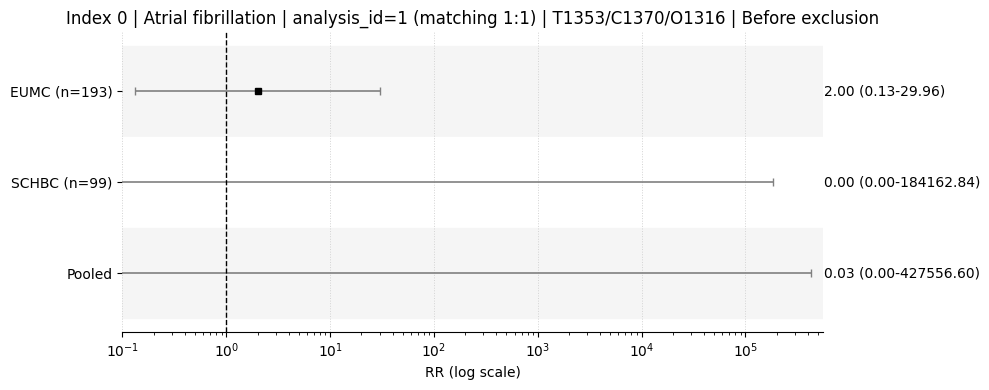

No pooled result (after exclusion). All hospitals may have been excluded.


In [ ]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# summary_df는 이미 만들어져 있다고 가정
# base_path도 이미 설정되어 있다고 가정
# 예: base_path = "/content/drive/MyDrive/파이썬 실행 위한 데이터/0114/escitalopram vs trazodone_0114"

def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def extract_matching_label(analysis_label: str) -> str:
    if analysis_label is None:
        return "matching: unknown"
    s = str(analysis_label)

    # "4:1 matching" 같은 형태 우선
    m = re.search(r"(\d+\s*:\s*\d+)\s*matching", s, flags=re.IGNORECASE)
    if m:
        return f"matching {m.group(1).replace(' ', '')}"

    # "4:1" 또는 "1:0" 같은 패턴만 있는 경우
    m = re.search(r"(\d+\s*:\s*\d+)", s)
    if m:
        return f"matching {m.group(1).replace(' ', '')}"

    return "matching: unknown"

def pick_n_subjects(row: pd.Series) -> float:
    """
    병원 수준 n(피험자 수) 추정:
    - 흔히 있는 컬럼: target_subjects / comparator_subjects
    - 또는 target_subjects / comparator_subjects 비슷한 이름
    - 있으면 min(target, comparator)을 n으로 사용
    - 없으면 outcome 사건수 기반(target_outcomes/comparator_outcomes)로 대체(최후수단)
    """
    # 후보 컬럼명들(대소문자/언더바 변형 대비)
    candidates_target = ["target_subjects", "targetsubjects", "target_subject"]
    candidates_comp   = ["comparator_subjects", "comparatorsubjects", "comparator_subject"]

    cols = {c.lower(): c for c in row.index}

    t = np.nan
    c = np.nan

    for k in candidates_target:
        if k in cols:
            t = safe_float(row[cols[k]])
            break

    for k in candidates_comp:
        if k in cols:
            c = safe_float(row[cols[k]])
            break

    if np.isfinite(t) and np.isfinite(c):
        return float(min(t, c))

    # 최후수단: 사건수(-5 치환된 target_outcomes/comparator_outcomes)
    for k in ["target_outcomes", "targetoutcomes"]:
        if k in cols:
            t = safe_float(row[cols[k]])
            break
    for k in ["comparator_outcomes", "comparatoroutcomes"]:
        if k in cols:
            c = safe_float(row[cols[k]])
            break

    if np.isfinite(t) and np.isfinite(c):
        return float(min(t, c))

    return np.nan

def normalize_cols_kwmc_style(df: pd.DataFrame) -> pd.DataFrame:
    """
    네 파일들(예: KWMC_cohort_method_result.csv, analysisSummary 구조)에 맞춘 최소 정규화.
    """
    colmap = {}
    for c in df.columns:
        lc = c.lower()
        if lc in ["analysisid", "analysis_id"]:
            colmap[c] = "analysis_id"
        elif lc in ["targetid", "target_id"]:
            colmap[c] = "target_id"
        elif lc in ["comparatorid", "comparator_id"]:
            colmap[c] = "comparator_id"
        elif lc in ["outcomeid", "outcome_id"]:
            colmap[c] = "outcome_id"
        elif lc in ["logrr", "log_rr"]:
            colmap[c] = "log_rr"
        elif lc in ["selogrr", "se_log_rr"]:
            colmap[c] = "se_log_rr"
        elif lc in ["databaseid", "database_id"]:
            colmap[c] = "database_id"
        # n 관련 가능 컬럼도 그대로 두되(이름 유지), 사건수도 유지
        elif lc in ["target_outcomes", "targetoutcomes"]:
            colmap[c] = "target_outcomes"
        elif lc in ["comparator_outcomes", "comparatoroutcomes"]:
            colmap[c] = "comparator_outcomes"
    return df.rename(columns=colmap)

def get_dbid_from_filename(fp: str) -> str:
    return os.path.basename(fp).split("_")[0]

def build_hospital_level_df_for_one(summary_row: pd.Series, base_path: str) -> pd.DataFrame:
    """
    summary_df의 1행(=1 조합)에 대해 outcome 폴더에서 병원별 효과추정치를 모아 DF 생성
    """
    out_full = str(summary_row["outcome"])
    outcome_folder = out_full.split(" | ")[0].strip()   # "Atrial fibrillation | ..." -> "Atrial fibrillation"
    analysis_id = int(summary_row["analysis_id"])
    t_id = int(summary_row["target_id"])
    c_id = int(summary_row["comparator_id"])
    o_id = int(summary_row["outcome_id"])

    folder = os.path.join(base_path, outcome_folder)
    cm_files = glob.glob(os.path.join(folder, "*cohort_method_result.csv"))

    rows = []
    for fp in cm_files:
        dbid = get_dbid_from_filename(fp)
        df = pd.read_csv(fp)
        df = normalize_cols_kwmc_style(df)

        if "analysis_id" not in df.columns:
            continue

        df = df[df["analysis_id"] == analysis_id].copy()
        if df.empty:
            continue

        # outcome_id는 (target_id, comparator_id)별 최소 1개만 사용
        if not {"target_id", "comparator_id", "outcome_id"}.issubset(df.columns):
            continue
        df = df.dropna(subset=["target_id", "comparator_id", "outcome_id"]).copy()
        df["outcome_id"] = df["outcome_id"].astype(int)

        min_o = df.groupby(["target_id", "comparator_id"])["outcome_id"].min().reset_index()
        df = df.merge(min_o, on=["target_id", "comparator_id", "outcome_id"], how="inner")

        # 해당 조합만
        df_tc = df[
            (df["target_id"] == t_id) &
            (df["comparator_id"] == c_id) &
            (df["outcome_id"] == o_id)
        ].copy()
        if df_tc.empty:
            continue

        # 효과추정치 필수
        if not {"log_rr", "se_log_rr"}.issubset(df_tc.columns):
            continue
        df_tc = df_tc.dropna(subset=["log_rr", "se_log_rr"])
        if df_tc.empty:
            continue

        # cohort_method_result는 보통 해당 조합 1행
        r = df_tc.iloc[0]

        log_rr = float(r["log_rr"])
        se = float(r["se_log_rr"])
        rr = float(np.exp(log_rr))
        ci_low = float(np.exp(log_rr - 1.96 * se))
        ci_high = float(np.exp(log_rr + 1.96 * se))

        n = pick_n_subjects(r)

        rows.append({
            "database_id": dbid,
            "n": n,
            "rr": rr,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "log_rr": log_rr,
            "se_log_rr": se,
        })

    return pd.DataFrame(rows)

def meta_random_from_log(log_rr, se_log_rr):
    y = np.asarray(log_rr, dtype=float)
    se = np.asarray(se_log_rr, dtype=float)
    v = se**2
    k = len(y)
    if k == 0:
        return None

    w = 1.0 / v
    y_bar = np.sum(w * y) / np.sum(w)
    Q = np.sum(w * (y - y_bar)**2)
    df = k - 1

    if k <= 1:
        tau2 = 0.0
    else:
        denom = np.sum(w) - (np.sum(w**2)/np.sum(w))
        tau2 = max(0.0, (Q - df) / denom) if denom > 0 else 0.0

    w_re = 1.0 / (v + tau2)
    mu = np.sum(w_re * y) / np.sum(w_re)
    se_mu = np.sqrt(1.0 / np.sum(w_re))

    return {
        "k": k,
        "rr": float(np.exp(mu)),
        "ci_low": float(np.exp(mu - 1.96 * se_mu)),
        "ci_high": float(np.exp(mu + 1.96 * se_mu)),
        "tau2": float(tau2),
    }

def plot_forest(hosp_df: pd.DataFrame, pooled: dict, title: str):
    if hosp_df.empty:
        print("No hospital-level rows to plot.")
        return

    df = hosp_df.copy().reset_index(drop=True)

    # y 라벨: 병원 + n
    df["label"] = df.apply(lambda r: f"{r['database_id']} (n={int(r['n'])})" if np.isfinite(r["n"]) else f"{r['database_id']} (n=NA)", axis=1)

    # pooled를 맨 아래에 추가
    pooled_row = pd.DataFrame([{
        "database_id": "Pooled",
        "n": np.nan,
        "rr": pooled["rr"],
        "ci_low": pooled["ci_low"],
        "ci_high": pooled["ci_high"],
        "label": "Pooled"
    }])
    df2 = pd.concat([df, pooled_row], ignore_index=True)

    y_pos = np.arange(len(df2))
    fig_height = max(4, 0.35 * len(df2) + 2)
    fig, ax = plt.subplots(figsize=(10, fig_height))

    # 배경 줄무늬
    for i, y in enumerate(y_pos):
        ax.axhspan(y - 0.5, y + 0.5, color="#f5f5f5" if i % 2 == 0 else "white", zorder=0)

    rr = df2["rr"].values
    lcl = df2["ci_low"].values
    ucl = df2["ci_high"].values
    xerr = np.vstack([rr - lcl, ucl - rr])

    # pooled는 diamond 대신 point로만 두고 싶으면 그대로 둬도 됨
    ax.errorbar(rr, y_pos, xerr=xerr, fmt="s", markersize=5, capsize=3,
                lw=1.2, color="black", ecolor="gray")

    ax.axvline(1, color="black", linestyle="--", linewidth=1)

    xmin = max(0.1, np.nanmin(lcl) * 0.8)
    xmax = np.nanmax(ucl) * 1.3
    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df2["label"].tolist(), fontsize=10)
    ax.invert_yaxis()

    # 오른쪽에 숫자 표시
    x_text = xmax * 1.02
    for y, r, lo, up in zip(y_pos, rr, lcl, ucl):
        ax.text(x_text, y, f"{r:.2f} ({lo:.2f}-{up:.2f})", va="center", ha="left", fontsize=10)

    ax.set_xlabel("RR (log scale)")
    ax.set_title(title, fontsize=12)

    ax.grid(axis="x", linestyle=":", linewidth=0.7, color="lightgray")
    ax.grid(axis="y", visible=False)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()


# -------------------------
# 실험: summary_df index=0
# -------------------------
idx = 0
row0 = summary_df.loc[idx]

analysis_label = str(row0["analysis_label"])
matching_txt = extract_matching_label(analysis_label)

# 병원별 원자료 구성
hosp = build_hospital_level_df_for_one(row0, base_path=base_path)

# pooled(제외 전)
pooled_all = meta_random_from_log(hosp["log_rr"], hosp["se_log_rr"]) if not hosp.empty else None

# 제외 조건 적용: n<30 제외, upper CI > 10 제외
hosp_filt = hosp.copy()
hosp_filt = hosp_filt[~(hosp_filt["n"].notna() & (hosp_filt["n"] < 30))].copy()
hosp_filt = hosp_filt[~(hosp_filt["ci_high"] > 10)].copy()

pooled_filt = meta_random_from_log(hosp_filt["log_rr"], hosp_filt["se_log_rr"]) if not hosp_filt.empty else None

# 제목용 문자열
outcome_name = str(row0["outcome"]).split(" | ")[0].strip()
t_id = int(row0["target_id"]); c_id = int(row0["comparator_id"]); o_id = int(row0["outcome_id"])
a_id = int(row0["analysis_id"])

title_base = f"Index {idx} | {outcome_name} | analysis_id={a_id} ({matching_txt}) | T{t_id}/C{c_id}/O{o_id}"

# forest plot: 제외 전
if pooled_all is not None:
    plot_forest(hosp, pooled_all, title=f"{title_base} | Before exclusion")
else:
    print("No pooled result (before exclusion). Check hospital-level extraction.")

# forest plot: 제외 후
if pooled_filt is not None:
    plot_forest(hosp_filt, pooled_filt, title=f"{title_base} | After exclusion (n>=30, upperCI<=10)")
else:
    print("No pooled result (after exclusion). All hospitals may have been excluded.")


# 반영된 정제된 summary df

In [ ]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------
# 1) 랜덤효과 메타분석 함수 (DerSimonian-Laird) - 네가 준 버전
# ---------------------------------------------------
def meta_random_from_log(log_rr, se_log_rr):
    y = np.asarray(log_rr, dtype=float)
    se = np.asarray(se_log_rr, dtype=float)
    v = se**2

    k = len(y)
    if k == 0:
        return {
            "k": 0,
            "rr": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "tau2": np.nan,
            "I2": np.nan,
        }

    w_fixed = 1.0 / v
    y_fixed = np.sum(w_fixed * y) / np.sum(w_fixed)

    Q = np.sum(w_fixed * (y - y_fixed)**2)
    df = k - 1

    if k <= 1:
        tau2 = 0.0
    else:
        denom = np.sum(w_fixed) - (np.sum(w_fixed**2) / np.sum(w_fixed))
        tau2 = max(0.0, (Q - df) / denom) if denom > 0 else 0.0

    if Q <= df or Q == 0:
        I2 = 0.0
    else:
        I2 = max(0.0, min(100.0, (Q - df) / Q * 100.0))

    w_random = 1.0 / (v + tau2)
    y_random = np.sum(w_random * y) / np.sum(w_random)
    se_random = np.sqrt(1.0 / np.sum(w_random))

    rr = np.exp(y_random)
    ci_low = np.exp(y_random - 1.96 * se_random)
    ci_high = np.exp(y_random + 1.96 * se_random)

    return {
        "k": k,
        "rr": rr,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "tau2": tau2,
        "I2": I2,
    }


# ---------------------------------------------------
# 2) 유틸
# ---------------------------------------------------
def get_dbid_from_filename(fp: str) -> str:
    return os.path.basename(fp).split("_")[0]

def normalize_cols_kwmc_style(df: pd.DataFrame) -> pd.DataFrame:
    colmap = {}
    for c in df.columns:
        lc = c.lower()
        if lc in ["analysisid", "analysis_id"]:
            colmap[c] = "analysis_id"
        elif lc in ["targetid", "target_id"]:
            colmap[c] = "target_id"
        elif lc in ["comparatorid", "comparator_id"]:
            colmap[c] = "comparator_id"
        elif lc in ["outcomeid", "outcome_id"]:
            colmap[c] = "outcome_id"
        elif lc in ["logrr", "log_rr"]:
            colmap[c] = "log_rr"
        elif lc in ["selogrr", "se_log_rr"]:
            colmap[c] = "se_log_rr"

        # subjects 후보
        elif lc in ["target_subjects", "targetsubjects"]:
            colmap[c] = "target_subjects"
        elif lc in ["comparator_subjects", "comparatorsubjects"]:
            colmap[c] = "comparator_subjects"

        # 사건수 후보(여기서는 n 부족시 fallback용)
        elif lc in ["target_outcomes", "targetoutcomes"]:
            colmap[c] = "target_outcomes"
        elif lc in ["comparator_outcomes", "comparatoroutcomes"]:
            colmap[c] = "comparator_outcomes"

    return df.rename(columns=colmap)

def pick_n_subjects_from_row(r: pd.Series) -> float:
    t = np.nan
    c = np.nan

    if "target_subjects" in r.index:
        t = pd.to_numeric(r["target_subjects"], errors="coerce")
    if "comparator_subjects" in r.index:
        c = pd.to_numeric(r["comparator_subjects"], errors="coerce")

    if np.isfinite(t) and np.isfinite(c):
        return float(min(t, c))

    # fallback: outcomes (최후수단)
    t2 = np.nan
    c2 = np.nan
    if "target_outcomes" in r.index:
        t2 = pd.to_numeric(r["target_outcomes"], errors="coerce")
    if "comparator_outcomes" in r.index:
        c2 = pd.to_numeric(r["comparator_outcomes"], errors="coerce")

    if np.isfinite(t2) and np.isfinite(c2):
        return float(min(t2, c2))

    return np.nan

def extract_matching_label(analysis_label: str) -> str:
    if analysis_label is None:
        return "matching: unknown"
    s = str(analysis_label)

    m = re.search(r"(\d+\s*:\s*\d+)\s*matching", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).replace(" ", "")

    m = re.search(r"(\d+\s*:\s*\d+)", s)
    if m:
        return m.group(1).replace(" ", "")

    return "unknown"


# ---------------------------------------------------
# 3) outcome 폴더별 병원 파일 캐시 로딩
#    (속도 때문에 outcome별로 한 번만 읽어둠)
# ---------------------------------------------------
def load_outcome_cache(base_path: str, outcome_folder: str):
    folder = os.path.join(base_path, outcome_folder)
    cm_files = glob.glob(os.path.join(folder, "*cohort_method_result.csv"))

    cache = {}
    for fp in cm_files:
        dbid = get_dbid_from_filename(fp)
        df = pd.read_csv(fp)
        df = normalize_cols_kwmc_style(df)

        # database_id가 있으면 유지, 없으면 dbid로 채움
        if "database_id" not in df.columns:
            df["database_id"] = dbid
        else:
            df["database_id"] = df["database_id"].astype(str)

        cache[str(dbid)] = df

    return cache


# ---------------------------------------------------
# 4) summary_df의 한 행(index 1개)에 대해 병원별 row 추출 + 필터 + 재메타
# ---------------------------------------------------
def hospital_rows_for_one(summary_row: pd.Series, outcome_cache: dict):
    analysis_id = int(summary_row["analysis_id"])
    t_id = int(summary_row["target_id"])
    c_id = int(summary_row["comparator_id"])
    o_id = int(summary_row["outcome_id"])

    rows = []

    for dbid, df in outcome_cache.items():
        if "analysis_id" not in df.columns:
            continue

        dfa = df[df["analysis_id"] == analysis_id].copy()
        if dfa.empty:
            continue

        if not {"target_id", "comparator_id", "outcome_id"}.issubset(dfa.columns):
            continue

        dfa = dfa.dropna(subset=["target_id", "comparator_id", "outcome_id"]).copy()
        if dfa.empty:
            continue

        dfa["outcome_id"] = dfa["outcome_id"].astype(int)

        # outcome_id는 (target_id, comparator_id)별 최소 1개만
        min_o = dfa.groupby(["target_id", "comparator_id"])["outcome_id"].min().reset_index()
        dfa = dfa.merge(min_o, on=["target_id", "comparator_id", "outcome_id"], how="inner")
        if dfa.empty:
            continue

        df_tc = dfa[
            (dfa["target_id"] == t_id) &
            (dfa["comparator_id"] == c_id) &
            (dfa["outcome_id"] == o_id)
        ].copy()
        if df_tc.empty:
            continue

        if not {"log_rr", "se_log_rr"}.issubset(df_tc.columns):
            continue

        df_tc = df_tc.dropna(subset=["log_rr", "se_log_rr"])
        if df_tc.empty:
            continue

        r = df_tc.iloc[0]

        log_rr = float(pd.to_numeric(r["log_rr"], errors="coerce"))
        se = float(pd.to_numeric(r["se_log_rr"], errors="coerce"))
        if not np.isfinite(log_rr) or not np.isfinite(se) or se <= 0:
            continue

        rr = float(np.exp(log_rr))
        ci_low = float(np.exp(log_rr - 1.96 * se))
        ci_high = float(np.exp(log_rr + 1.96 * se))
        n = pick_n_subjects_from_row(r)

        rows.append({
            "database_id": str(dbid),
            "n": n,
            "log_rr": log_rr,
            "se_log_rr": se,
            "rr": rr,
            "ci_low": ci_low,
            "ci_high": ci_high
        })

    return pd.DataFrame(rows)


# ---------------------------------------------------
# 5) 전체 index에 대해 정제 pooled 결과 만들기
# ---------------------------------------------------
# base_path는 너가 쓰는 S1215 경로로 유지
# 예: base_path = "/content/drive/MyDrive/파이썬 실행 위한 데이터/0114/escitalopram vs trazodone_0114"

refined_records = []

# outcome 폴더 캐시: outcome_folder -> {dbid: df}
outcome_cache_map = {}

for idx, r in summary_df.reset_index(drop=False).iterrows():
    # 원래 summary_df의 index를 같이 저장
    original_index = int(r["index"]) if "index" in r.index else int(idx)

    # outcome 폴더명은 "Atrial fibrillation | ..."에서 앞부분
    outcome_folder = str(r["outcome"]).split(" | ")[0].strip()

    if outcome_folder not in outcome_cache_map:
        outcome_cache_map[outcome_folder] = load_outcome_cache(base_path, outcome_folder)

    cache = outcome_cache_map[outcome_folder]

    hosp = hospital_rows_for_one(r, cache)

    # 제외 전 pooled
    pooled_before = meta_random_from_log(hosp["log_rr"], hosp["se_log_rr"]) if not hosp.empty else None

    # 제외 조건: 병원 수준 n<30 제외, upper CI > 10 제외
    hosp_after = hosp.copy()
    hosp_after = hosp_after[~(hosp_after["n"].notna() & (hosp_after["n"] < 30))].copy()
    hosp_after = hosp_after[~(hosp_after["ci_high"] > 10)].copy()

    pooled_after = meta_random_from_log(hosp_after["log_rr"], hosp_after["se_log_rr"]) if not hosp_after.empty else None

    analysis_label = str(r["analysis_label"]) if "analysis_label" in r.index else ""
    matching = extract_matching_label(analysis_label)

    # refined pooled(After exclusion)만 forest plot에 쓸 거라면 after만 저장해도 됨.
    # 여기서는 before/after 둘 다 저장해둠.
    rec = {
        "original_index": original_index,
        "outcome": str(r["outcome"]),
        "outcome_folder": outcome_folder,
        "analysis_id": int(r["analysis_id"]),
        "analysis_label": analysis_label,
        "matching": matching,
        "target_id": int(r["target_id"]),
        "comparator_id": int(r["comparator_id"]),
        "outcome_id": int(r["outcome_id"]),
        "hospitals_before": int(len(hosp)),
        "hospitals_after": int(len(hosp_after)),
    }

    if pooled_before is None:
        rec.update({
            "rr_before": np.nan, "ci_low_before": np.nan, "ci_high_before": np.nan, "tau2_before": np.nan, "I2_before": np.nan, "k_before": 0
        })
    else:
        rec.update({
            "rr_before": pooled_before["rr"],
            "ci_low_before": pooled_before["ci_low"],
            "ci_high_before": pooled_before["ci_high"],
            "tau2_before": pooled_before["tau2"],
            "I2_before": pooled_before["I2"],
            "k_before": pooled_before["k"],
        })

    if pooled_after is None:
        rec.update({
            "rr_random": np.nan, "ci_low": np.nan, "ci_high": np.nan, "tau2": np.nan, "I2": np.nan, "k_hospitals": 0
        })
    else:
        rec.update({
            "rr_random": pooled_after["rr"],
            "ci_low": pooled_after["ci_low"],
            "ci_high": pooled_after["ci_high"],
            "tau2": pooled_after["tau2"],
            "I2": pooled_after["I2"],
            "k_hospitals": pooled_after["k"],
        })

    refined_records.append(rec)

refined_summary_df = pd.DataFrame(refined_records)

# 정제 pooled 결과(After exclusion)만 보려면
refined_summary_df.head()


,original_index,outcome,outcome_folder,analysis_id,analysis_label,matching,target_id,comparator_id,outcome_id,hospitals_before,...,ci_high_before,tau2_before,I2_before,k_before,rr_random,ci_low,ci_high,tau2,I2,k_hospitals
0,0,Atrial fibrillation | LR 5yr_cox_remove all 1:1,Atrial fibrillation,1,LR 5yr_cox_remove all 1:1,1:1,1353,1370,1316,2,...,427556.596062,84.397328,37.7778,2,NaN,NaN,NaN,NaN,NaN,0
1,1,Atrial fibrillation | LR 3yrs_logistic_removea...,Atrial fibrillation,2,LR 3yrs_logistic_removeall 1:1,1:1,1353,1370,1316,1,...,4.187054,0.000000,0.0000,1,0.333333,0.026537,4.187054,0.0,0.0,1
2,2,Atrial fibrillation | LR 1yr_cox_remove all 1:1,Atrial fibrillation,4,LR 1yr_cox_remove all 1:1,1:1,1353,1370,1316,1,...,184162.836268,0.000000,0.0000,1,NaN,NaN,NaN,NaN,NaN,0
3,3,Atrial fibrillation | LR 3yrs_cox__remove all 1:1,Atrial fibrillation,5,LR 3yrs_cox__remove all 1:1,1:1,1353,1370,1316,1,...,184162.836268,0.000000,0.0000,1,NaN,NaN,NaN,NaN,NaN,0
4,4,Atrial fibrillation | LR 5yr_logistic_remove a...,Atrial fibrillation,6,LR 5yr_logistic_remove all 1:1,1:1,1353,1370,1316,1,...,4.512271,0.000000,0.0000,1,0.666667,0.098497,4.512271,0.0,0.0,1


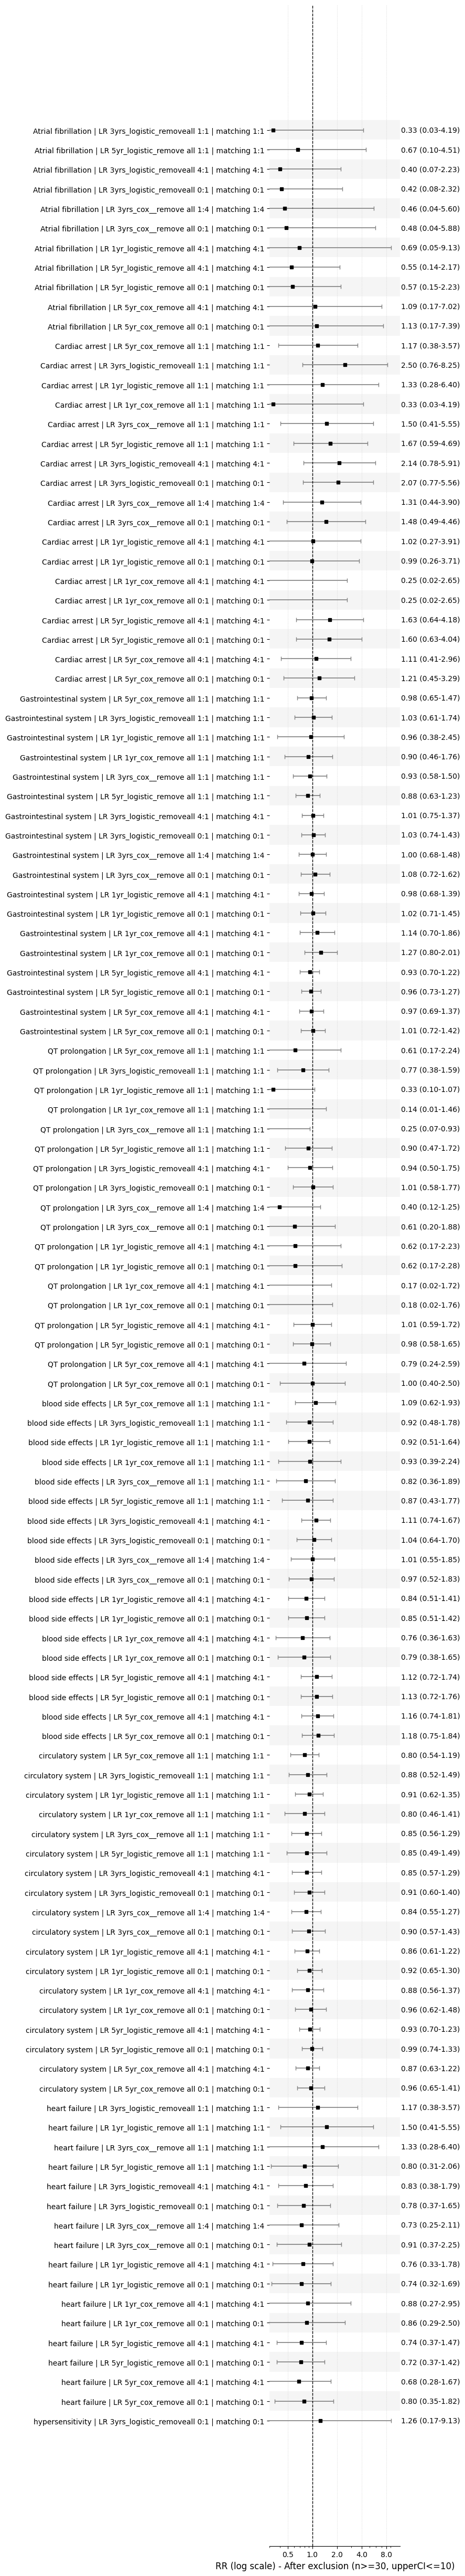

In [ ]:
df = refined_summary_df.copy()

rr_col  = "rr_random"
lcl_col = "ci_low"
ucl_col = "ci_high"

# 라벨에 matching까지 붙이고 싶으면 아래처럼 label_col을 새로 만들면 됨
df["label"] = df.apply(
    lambda r: f"{r['outcome']} | matching {r['matching']}" if pd.notna(r["matching"]) else str(r["outcome"]),
    axis=1
)
label_col = "label"

df_plot = df.dropna(subset=[rr_col, lcl_col, ucl_col]).reset_index(drop=True)

outcomes = df_plot[label_col].tolist()
y_pos = np.arange(len(outcomes))

fig_height = max(4, 0.4 * len(outcomes) + 2)
fig, ax = plt.subplots(figsize=(9, fig_height))

for i, y in enumerate(y_pos):
    color = "#f5f5f5" if i % 2 == 0 else "white"
    ax.axhspan(y - 0.5, y + 0.5, color=color, zorder=0)

rr  = df_plot[rr_col].values
lcl = df_plot[lcl_col].values
ucl = df_plot[ucl_col].values
xerr = np.vstack([rr - lcl, ucl - rr])

ax.errorbar(rr, y_pos, xerr=xerr, fmt="s", markersize=5, capsize=3,
            lw=1.2, color="black", ecolor="gray")

ax.axvline(1, color="black", linestyle="--", linewidth=1)

xmin = max(0.3, np.nanmin(lcl) * 0.8)
xmax = np.nanmax(ucl) * 1.3
ax.set_xscale("log")
ax.set_xlim(xmin, xmax)

ticks = [0.25, 0.5, 1, 2, 4, 8]
ticks = [t for t in ticks if xmin <= t <= xmax]
ax.set_xticks(ticks)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())

ax.set_yticks(y_pos)
ax.set_yticklabels(outcomes, fontsize=10)
ax.invert_yaxis()

x_text = xmax * 1.02
for y, r, lo, up in zip(y_pos, rr, lcl, ucl):
    ax.text(x_text, y, f"{r:.2f} ({lo:.2f}-{up:.2f})",
            va="center", ha="left", fontsize=10)

ax.set_xlabel("RR (log scale) - After exclusion (n>=30, upperCI<=10)", fontsize=12)

ax.grid(axis="x", linestyle=":", linewidth=0.7, color="lightgray")
ax.grid(axis="y", visible=False)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


analysis id 하나 선택하는 과정

In [ ]:
# 결과가 있는 행만 기준(제외 후 pooled가 계산된 경우)
df_ok = refined_summary_df.dropna(subset=["rr_random", "ci_low", "ci_high"]).copy()

# outcome 단위 키 (폴더명 기준이 제일 깔끔)
outcome_key = "outcome_folder" if "outcome_folder" in df_ok.columns else "outcome"

# outcome별로 존재하는 analysis_id 집합
sets_by_outcome = df_ok.groupby(outcome_key)["analysis_id"].apply(lambda s: set(s.unique()))

# 교집합 (모든 outcome에서 공통으로 존재하는 analysis_id)
common_analysis_ids = sorted(set.intersection(*sets_by_outcome.tolist())) if len(sets_by_outcome) > 0 else []

print("Common analysis_ids across ALL outcomes:", common_analysis_ids)
print("Count:", len(common_analysis_ids))


Common analysis_ids across ALL outcomes: [np.int64(8)]
Count: 1


In [ ]:
# 결과가 있는 행만(제외 후 pooled가 계산된 경우)
df_ok = refined_summary_df.dropna(subset=["rr_random", "ci_low", "ci_high"]).copy()

outcome_key = "outcome_folder" if "outcome_folder" in df_ok.columns else "outcome"

# analysis_id별로 "서로 다른 outcome"이 몇 개인지(=커버리지) 집계
coverage = (
    df_ok.groupby(["analysis_id", "analysis_label", "matching"], dropna=False)[outcome_key]
    .nunique()
    .reset_index(name="n_outcomes_with_result")
    .sort_values(["n_outcomes_with_result", "analysis_id"], ascending=[False, True])
    .reset_index(drop=True)
)

coverage.head(30)


,analysis_id,analysis_label,matching,n_outcomes_with_result
0,8,LR 3yrs_logistic_removeall 0:1,0:1,8
1,2,LR 3yrs_logistic_removeall 1:1,1:1,7
2,6,LR 5yr_logistic_remove all 1:1,1:1,7
3,7,LR 3yrs_logistic_removeall 4:1,4:1,7
4,9,LR 3yrs_cox__remove all 1:4,1:4,7
5,10,LR 3yrs_cox__remove all 0:1,0:1,7
6,11,LR 1yr_logistic_remove all 4:1,4:1,7
7,15,LR 5yr_logistic_remove all 4:1,4:1,7
8,16,LR 5yr_logistic_remove all 0:1,0:1,7
9,17,LR 5yr_cox_remove all 4:1,4:1,7


# analysis id, matching 반영 summary df

In [ ]:
import pandas as pd
import numpy as np
import re
import os

# =========================================================
# 0) 데이터 확인
# =========================================================
# refined_summary_df가 이미 메모리에 로드되어 있어야 합니다.
if 'refined_summary_df' not in locals():
    raise NameError("refined_summary_df가 정의되지 않았습니다. 데이터를 먼저 로드해주세요.")

# =========================================================
# 1) Analysis Map 엑셀 로드 및 컬럼 자동 탐지
# =========================================================
analysis_map_path = "/content/drive/MyDrive/파이썬 실행 위한 데이터/18 analysisId 항목_0114.xlsx"
am = pd.read_excel(analysis_map_path)

# 1-1) analysis_id 컬럼 자동 탐지
id_col = None
for c in am.columns:
    if str(c).strip().lower().replace(" ", "").replace("_","") in ["analysisid", "analysis_id", "analysisid번호", "analysisidnum", "id"]:
        id_col = c
        break
if id_col is None:
    numeric_cols = [c for c in am.columns if pd.api.types.is_numeric_dtype(am[c])]
    best = None
    best_score = -1
    for c in numeric_cols:
        vals = set(pd.to_numeric(am[c], errors="coerce").dropna().astype(int).tolist())
        score = len([x for x in vals if 1 <= x <= 48])
        if score > best_score:
            best_score = score
            best = c
    id_col = best

# 1-2) matching 컬럼 자동 탐지
def has_matching_token(s):
    if pd.isna(s): return False
    s = str(s)
    return bool(re.search(r"(\b\d+\s*:\s*\d+\b|\bn\s*:\s*\d+\b|\b\d+\s*:\s*n\b|\b1\s*:\s*n\b|\bn\s*:\s*1\b)", s, flags=re.IGNORECASE))

match_col = None
best_cnt = 0
for c in am.columns:
    if c == id_col: continue
    cnt = am[c].apply(has_matching_token).sum()
    if cnt > best_cnt:
        best_cnt = cnt
        match_col = c

if match_col is None or best_cnt == 0:
    raise ValueError("엑셀에서 matching 정보를 가진 컬럼을 찾지 못했습니다.")

# =========================================================
# 2) Matching 문자열 표준화 함수
# =========================================================
def normalize_matching(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().lower().replace(" ", "").replace("matching", "").replace("match", "")
    m = re.search(r"(\d+:\d+|n:1|1:n|\d+:n|n:\d+)", s)
    return m.group(1).replace("N", "n") if m else np.nan

am2 = am[[id_col, match_col]].copy()
am2[id_col] = pd.to_numeric(am2[id_col], errors="coerce").astype("Int64")
am2["matching_std"] = am2[match_col].apply(normalize_matching)

analysis_id_to_matching = dict(
    am2.dropna(subset=[id_col, "matching_std"])
       .astype({id_col: int})
       .set_index(id_col)["matching_std"]
       .to_dict()
)

# =========================================================
# 3) refined_summary_df에 matching 반영
# =========================================================
refined_summary_df_matched = refined_summary_df.copy()
refined_summary_df_matched["matching"] = refined_summary_df_matched["analysis_id"].map(analysis_id_to_matching)
refined_summary_df_matched["matching"] = refined_summary_df_matched["matching"].replace({"unknown": np.nan, "Unknown": np.nan})

# =========================================================
# 4) 모든 Analysis_ID 추출 (조건 제한 없음)
# =========================================================
# 결과(RR, CI)가 있는 유효 행들만 대상으로 집계
df_ok = refined_summary_df_matched.dropna(subset=["rr_random", "ci_low", "ci_high"]).copy()
outcome_key = "outcome_folder" if "outcome_folder" in df_ok.columns else "outcome"

coverage = (
    df_ok.groupby(["analysis_id", "analysis_label", "matching"], dropna=False)[outcome_key]
    .nunique()
    .reset_index(name="n_outcomes_with_result")
    .sort_values(["n_outcomes_with_result", "analysis_id"], ascending=[False, True])
    .reset_index(drop=True)
)

# [수정] 특정 숫자(8 등) 필터링 없이 모든 ID 리스트업
analysis_ids_all = coverage["analysis_id"].astype(int).tolist()
df_all = df_ok[df_ok["analysis_id"].isin(analysis_ids_all)].copy()

# =========================================================
# 5) 결과 확인
# =========================================================
print("-" * 50)
print(f"✅ 모든 유효한 analysis_id 추출 완료 (총 {len(analysis_ids_all)}개)")
print(f"📍 ID 목록: {analysis_ids_all}")
print("-" * 50)

# 요약 테이블 및 매칭 결과 확인
display(coverage)
display(df_all[["analysis_id", "analysis_label", "matching"]].drop_duplicates().sort_values("analysis_id").head(30))

--------------------------------------------------
✅ 모든 유효한 analysis_id 추출 완료 (총 18개)
📍 ID 목록: [8, 2, 6, 7, 9, 10, 11, 15, 16, 17, 18, 3, 5, 12, 13, 14, 1, 4]
--------------------------------------------------


,analysis_id,analysis_label,matching,n_outcomes_with_result
0,8,LR 3yrs_logistic_removeall 0:1,0:1,8
1,2,LR 3yrs_logistic_removeall 1:1,1:1,7
2,6,LR 5yr_logistic_remove all 1:1,1:1,7
3,7,LR 3yrs_logistic_removeall 4:1,4:1,7
4,9,LR 3yrs_cox__remove all 1:4,1:4,7
5,10,LR 3yrs_cox__remove all 0:1,0:1,7
6,11,LR 1yr_logistic_remove all 4:1,4:1,7
7,15,LR 5yr_logistic_remove all 4:1,4:1,7
8,16,LR 5yr_logistic_remove all 0:1,0:1,7
9,17,LR 5yr_cox_remove all 4:1,4:1,7


,analysis_id,analysis_label,matching
17,1,LR 5yr_cox_remove all 1:1,1:1
1,2,LR 3yrs_logistic_removeall 1:1,1:1
19,3,LR 1yr_logistic_remove all 1:1,1:1
20,4,LR 1yr_cox_remove all 1:1,1:1
21,5,LR 3yrs_cox__remove all 1:1,1:1
4,6,LR 5yr_logistic_remove all 1:1,1:1
5,7,LR 3yrs_logistic_removeall 4:1,4:1
6,8,LR 3yrs_logistic_removeall 0:1,0:1
7,9,LR 3yrs_cox__remove all 1:4,1:4
8,10,LR 3yrs_cox__remove all 0:1,0:1


# analysis id, matching 반영 forest plot

In [ ]:
import numpy as np
import pandas as pd

# =========================================================
# [Missing Logic] 누락된 함수 및 변수 정의
# =========================================================

# 1. drop_inestimable_outcomes 함수 정의
def drop_inestimable_outcomes(df):
    """
    RR, Lower CI, Upper CI 중 하나라도 NaN(결측치)이거나
    무한대(Inf)인 행을 제거하여 반환합니다.
    """
    # 전역 변수로 설정된 컬럼명 사용 (없으면 기본값 사용)
    r_col = rr_m if 'rr_m' in globals() else 'rr'
    l_col = lcl_m if 'lcl_m' in globals() else 'ci_low'
    u_col = ucl_m if 'ucl_m' in globals() else 'ci_high'

    # 1) 컬럼이 실제 존재하는지 확인
    cols_to_check = [c for c in [r_col, l_col, u_col] if c in df.columns]

    if not cols_to_check:
        return df # 체크할 컬럼이 없으면 그대로 반환

    # 2) NaN 제거
    df_out = df.dropna(subset=cols_to_check).copy()

    # 3) 무한대(Inf) 제거 (Log scale 그래프 에러 방지)
    # 수치형 데이터만 선택하여 inf 검사
    numeric_cols = df_out[cols_to_check].select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        mask_finite = np.isfinite(df_out[numeric_cols]).all(axis=1)
        df_out = df_out[mask_finite]

    return df_out

# 2. fmt 함수 정의 (ax.text 부분에서 사용됨)
if 'fmt' not in globals():
    # 소수점 2자리 포맷팅 함수
    fmt = lambda x: f"{float(x):.2f}"

# 3. 필수 전역 변수 체크 (rr_m, lcl_m, ucl_m이 없으면 기본값 할당)
#    사용자 환경에 맞게 컬럼명을 수정하세요.
if 'rr_m' not in globals(): rr_m = 'rr_random'  # 또는 'rr'
if 'lcl_m' not in globals(): lcl_m = 'ci_low_x' # 또는 'ci_low'
if 'ucl_m' not in globals(): ucl_m = 'ci_high_x' # 또는 'ci_high'
if 'outcome_key' not in globals(): outcome_key = 'outcome_folder' # 또는 'outcome'

print("✅ 누락된 함수(drop_inestimable_outcomes, fmt)와 변수가 정의되었습니다.")

✅ 누락된 함수(drop_inestimable_outcomes, fmt)와 변수가 정의되었습니다.


In [ ]:
import pandas as pd

# =========================================================
# 🛠️ 컬럼명 자동 보정 (Auto-Correction)
# =========================================================

# 1. 현재 df_ok에 있는 실제 컬럼들 확인
current_cols = set(df_ok.columns)
print(f"📋 현재 데이터프레임 컬럼 목록 (일부): {list(current_cols)[:10]} ...")

# 2. RR / LCL / UCL 후보군 정의
candidates_rr = ['rr_random', 'rr', 'RR', 'est', 'or', 'OR']
candidates_lcl = ['ci_low_x', 'ci_low', 'lower', 'LCL', 'ci_low_y']
candidates_ucl = ['ci_high_x', 'ci_high', 'upper', 'UCL', 'ci_high_y']

# 3. 실제 존재하는 컬럼 찾기 함수
def find_existing_col(candidates, cols):
    for c in candidates:
        if c in cols:
            return c
    return None

# 4. 변수 재할당
new_rr_m = find_existing_col(candidates_rr, current_cols)
new_lcl_m = find_existing_col(candidates_lcl, current_cols)
new_ucl_m = find_existing_col(candidates_ucl, current_cols)

# 5. 결과 검증
if new_rr_m and new_lcl_m and new_ucl_m:
    rr_m = new_rr_m
    lcl_m = new_lcl_m
    ucl_m = new_ucl_m
    print("\n✅ 컬럼 매핑 성공!")
    print(f"   - RR  컬럼: '{rr_m}'")
    print(f"   - LCL 컬럼: '{lcl_m}' (기존 에러 원인 해결)")
    print(f"   - UCL 컬럼: '{ucl_m}'")
else:
    print("\n❌ 자동 매핑 실패. 데이터프레임 컬럼을 직접 확인해야 합니다.")
    print(f"   - 찾은 것: RR={new_rr_m}, LCL={new_lcl_m}, UCL={new_ucl_m}")
    # 강제로 중단하여 확인 유도
    raise ValueError("필수 컬럼을 찾지 못했습니다. 위의 컬럼 목록을 확인해주세요.")

📋 현재 데이터프레임 컬럼 목록 (일부): ['k_before', 'k_hospitals', 'rr_before', 'outcome', 'hospitals_before', 'tau2_before', 'ci_low', 'ci_low_before', 'rr_random', 'tau2'] ...

✅ 컬럼 매핑 성공!
   - RR  컬럼: 'rr_random'
   - LCL 컬럼: 'ci_low' (기존 에러 원인 해결)
   - UCL 컬럼: 'ci_high'


In [ ]:
import pandas as pd

# =========================================================
# 🛠️ Missing Maps Fix (제목 라벨용 딕셔너리 생성)
# =========================================================

# 1. 요약 데이터프레임 찾기 (이름이 다양할 수 있어 순차 검색)
df_sum_source = None
if 'refined_summary_df_matched' in globals():
    df_sum_source = refined_summary_df_matched
elif 'refined_summary_df' in globals():
    df_sum_source = refined_summary_df
elif 'summary_df' in globals():
    df_sum_source = summary_df

# 2. 딕셔너리(Map) 생성
analysis_label_map = {}
matching_map = {}

if df_sum_source is not None:
    print(f"✅ 요약 데이터프레임({len(df_sum_source)} rows)을 찾았습니다. 맵핑을 생성합니다.")

    # analysis_label 컬럼이 있는지 확인
    if 'analysis_label' in df_sum_source.columns:
        analysis_label_map = df_sum_source.set_index('analysis_id')['analysis_label'].to_dict()
    else:
        print("   ⚠️ 'analysis_label' 컬럼이 없어 빈 값으로 설정합니다.")

    # matching 컬럼이 있는지 확인
    if 'matching' in df_sum_source.columns:
        matching_map = df_sum_source.set_index('analysis_id')['matching'].to_dict()
    else:
        print("   ⚠️ 'matching' 컬럼이 없어 빈 값으로 설정합니다.")
else:
    print("⚠️ 요약 데이터프레임을 찾을 수 없습니다. (refined_summary_df 등)")
    print("   👉 그래프 제목의 라벨과 매칭 정보는 'NA'로 표시됩니다.")
    # 코드가 멈추지 않도록 빈 딕셔너리로 초기화
    analysis_label_map = {}
    matching_map = {}

print("✅ 'analysis_label_map' 및 'matching_map' 초기화 완료.")

✅ 요약 데이터프레임(136 rows)을 찾았습니다. 맵핑을 생성합니다.
✅ 'analysis_label_map' 및 'matching_map' 초기화 완료.


In [ ]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

# =========================================================
# [필수] 이전 단계에서 정의된 변수들 확인
# rr_m, lcl_m, ucl_m, outcome_key, fmt, drop_inestimable_outcomes 등
# =========================================================

# 파일명 정제 함수 보강 (특수문자 및 공백 제거)
def safe_filename(s: str) -> str:
    s = str(s).strip().replace(" ", "_")
    return re.sub(r'(?u)[^-\w.]', '', s)

# 저장 경로 설정
save_dir = "/content/drive/MyDrive/파이썬"

def plot_and_save_forest_for_analysis_id(a_id: int, out_dir: str):
    # 1. 매번 폴더 존재 확인 (드라이브 연결 유실 방지)
    if not os.path.exists(out_dir):
        try:
            os.makedirs(out_dir, exist_ok=True)
        except Exception as e:
            print(f"❌ 폴더 생성 실패 (ID {a_id}): {e}")
            return False

    df_a = df_ok[df_ok["analysis_id"] == a_id].copy()
    if df_a.empty: return False

    # 데이터 준비
    df_meta = df_a.drop_duplicates(subset=[outcome_key]).copy()
    df_meta = drop_inestimable_outcomes(df_meta)
    if df_meta.empty: return False

    df_meta = df_meta.sort_values(outcome_key)
    outcomes = df_meta[outcome_key].astype(str).tolist()
    y_pos = np.arange(len(outcomes))

    rr, lcl, ucl = df_meta[rr_m].values, df_meta[lcl_m].values, df_meta[ucl_m].values
    xerr = np.vstack([rr - lcl, ucl - rr])

    # 그래프 그리기 (기존 형식 유지)
    fig_height = max(4, 0.45 * len(outcomes) + 2)
    fig, ax = plt.subplots(figsize=(11, fig_height))

    for i, y in enumerate(y_pos):
        ax.axhspan(y - 0.5, y + 0.5, color="#f5f5f5" if i % 2 == 0 else "white", zorder=0)

    ax.errorbar(rr, y_pos, xerr=xerr, fmt="s", markersize=5, capsize=3, lw=1.2, color="black", ecolor="gray")
    ax.axvline(1, color="black", linestyle="--", linewidth=1)
    ax.set_xscale("log")

    xmin_data = max(0.01, np.nanmin(lcl) * 0.8)
    xmax_data = np.nanmax(ucl) * 1.3
    pad = 1.50  # 1.15~1.50 사이에서 조절(클수록 좌우 공백 증가)
    xmin = xmin_data / pad
    xmax = xmax_data * pad
    ax.set_xlim(xmin, xmax)

    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_yticks(y_pos)
    ax.set_yticklabels(outcomes, fontsize=12)
    ax.invert_yaxis()

    # 우측 수치 텍스트
    x_text = xmax * 1.05
    for y, r, lo, up in zip(y_pos, rr, lcl, ucl):
        ax.text(x_text, y, f"{fmt(r)} ({fmt(lo)}-{fmt(up)})", va="center", ha="left", fontsize=11)

    a_label = analysis_label_map.get(a_id, "NA")
    m = matching_map.get(a_id, "NA")
    ax.set_title(f"analysis_id={a_id} | {a_label} | matching {m}\n", fontsize=12)
    ax.set_xlabel("RR (log scale)", fontsize=12)

    for spine in ["top", "right", "left"]: ax.spines[spine].set_visible(False)
    ax.grid(axis="x", linestyle=":", color="lightgray")
    plt.tight_layout()

    # 2. 파일명 길이 및 안정성 확보
    short_label = safe_filename(a_label)[:30] # 라벨 길이를 더 줄임
    fn = f"ID_{a_id}_{short_label}.png"
    full_path = os.path.join(out_dir, fn)

    # 3. 저장 시 예외 처리
    try:
        plt.savefig(full_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
        return True
    except Exception as e:
        print(f"❌ 저장 에러 (ID {a_id}): {e}")
        plt.close(fig)
        return False

# --- 저장 실행 ---
print(f"🚀 총 {len(analysis_ids_all)}개의 분석 ID 저장을 시작합니다.")
saved_count = 0

for a_id in analysis_ids_all:
    if plot_and_save_forest_for_analysis_id(a_id, save_dir):
        saved_count += 1
    else:
        # 실패 시 잠시 대기 후 재시도 하거나 건너뜀
        continue

print(f"\n✅ 완료! 총 {saved_count}개의 그래프가 성공적으로 저장되었습니다.")

🚀 총 18개의 분석 ID 저장을 시작합니다.

✅ 완료! 총 18개의 그래프가 성공적으로 저장되었습니다.


# 네모크기반영 forest plot

In [ ]:
import pandas as pd
from google.colab import drive
import os

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 파일 경로 설정
# (중요: '파이썬' 폴더 안에 있다면 아래 경로를 사용하세요. 실제 위치에 따라 수정이 필요할 수 있습니다.)
base_dir = '/content/drive/MyDrive'
file_name = 'es vs tra_0114_outcome_analysisid_hospital_n.xlsx'
file_path = os.path.join(base_dir, file_name)

# 3. 파일 읽기
try:
    # 확장자가 xlsx이므로 read_excel을 사용해야 합니다.
    # 만약 특정 시트(ALL_with_incl_excl)를 읽어야 한다면 sheet_name을 지정하세요.
    df_hosp = pd.read_excel(file_path, sheet_name='ALL_with_incl_excl')
    print("✅ 드라이브에서 파일을 성공적으로 불러왔습니다!")

    # 컬럼명 정리 및 필터링 (2단계 로직)
    df_hosp.columns = df_hosp.columns.str.strip()
    df_valid = df_hosp[df_hosp['is_included'] == True].copy()

    summary_df = df_valid.groupby(['analysis_id', 'outcome'])['n_min_tc'].sum().reset_index()
    summary_df.rename(columns={'n_min_tc': 'total_n_sum'}, inplace=True)

    print("\n📊 주요 Outcome 합산 결과 (검증):")
    display(summary_df[summary_df['outcome'].isin(['Atrial fibrillation', 'Cardiac arrest'])])

except Exception as e:
    print(f"❌ 에러 발생: {e}")
    print("팁: 파일이 '내 드라이브' 바로 아래에 있다면 base_dir을 '/content/drive/MyDrive'로 수정해보세요.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 드라이브에서 파일을 성공적으로 불러왔습니다!

📊 주요 Outcome 합산 결과 (검증):


,analysis_id,outcome,total_n_sum
0,1,Atrial fibrillation,68
1,1,Cardiac arrest,659
17,2,Atrial fibrillation,360
18,2,Cardiac arrest,845
34,3,Atrial fibrillation,240
35,3,Cardiac arrest,1216
51,4,Atrial fibrillation,141
52,4,Cardiac arrest,1017
68,5,Atrial fibrillation,141
69,5,Cardiac arrest,659


In [ ]:
import pandas as pd

# 1. 정규화 함수: '|' 앞부분만 취하고 공백 제거 및 소문자화
def normalize_outcome(text):
    if pd.isna(text): return ""
    # '|' 기호가 있으면 그 앞부분만 사용, 없으면 전체 사용
    main_name = str(text).split('|')[0]
    # 모든 공백 제거 및 소문자화
    return "".join(main_name.split()).lower()

# 2. summary_df에 매칭용 키 생성
summary_df_clean = summary_df.copy()
summary_df_clean['match_key'] = summary_df_clean['analysis_id'].astype(str) + "_" + \
                               summary_df_clean['outcome'].apply(normalize_outcome)

# 3. df_ok에 매칭용 키 생성
df_ok_clean = df_ok.copy()
df_ok_clean['match_key'] = df_ok_clean['analysis_id'].astype(str) + "_" + \
                          df_ok_clean['outcome'].apply(normalize_outcome)

# 4. 매칭 테스트
test_merge = pd.merge(
    df_ok_clean,
    summary_df_clean[['match_key', 'total_n_sum']],
    on='match_key',
    how='inner'
)

print(f"✅ [최종 테스트] 매칭된 행의 개수: {len(test_merge)}")

if len(test_merge) > 0:
    print("👍 매칭 성공! 이제 N수가 정상적으로 연결됩니다.")
    display(test_merge[['outcome', 'total_n_sum']].head())
else:
    print("❗ 여전히 매칭되지 않는다면 summary_df의 outcome 샘플을 다시 확인해야 합니다.")

✅ [최종 테스트] 매칭된 행의 개수: 118
👍 매칭 성공! 이제 N수가 정상적으로 연결됩니다.


,outcome,total_n_sum
0,Atrial fibrillation | LR 3yrs_logistic_removea...,360
1,Atrial fibrillation | LR 5yr_logistic_remove a...,360
2,Atrial fibrillation | LR 3yrs_logistic_removea...,433
3,Atrial fibrillation | LR 3yrs_logistic_removea...,433
4,Atrial fibrillation | LR 3yrs_cox__remove all 1:4,334


In [ ]:
def plot_and_save_forest_for_analysis_id(a_id, out_dir):
    df_plot = df_ok_clean[df_ok_clean['analysis_id'] == a_id].copy()
    if df_plot.empty: return False

    df_plot = pd.merge(df_plot, summary_df_clean[['match_key', 'total_n_sum']],
                       on='match_key', how='left')

    df_plot['total_n_sum'] = df_plot['total_n_sum'].fillna(30)
    display_outcomes = [str(name).split('|')[0].strip() for name in df_plot['outcome']]

    y_pos = np.arange(len(display_outcomes))
    rr = df_plot['rr_random'].values
    lcl = df_plot['ci_low'].values
    ucl = df_plot['ci_high'].values
    n_sums = df_plot['total_n_sum'].values

    # 1. 네모 크기 조절 (원하시는 대로 줄였습니다)
    dynamic_ms = np.sqrt(n_sums) * 0.2

    fig_height = max(4, 0.45 * len(display_outcomes) + 2)
    fig, ax = plt.subplots(figsize=(11, fig_height))

    for i, y in enumerate(y_pos):
        ax.axhspan(y - 0.5, y + 0.5, color="#f5f5f5" if i % 2 == 0 else "white", zorder=0)

    ax.errorbar(rr, y_pos, xerr=[rr-lcl, ucl-rr], fmt="none", capsize=3, lw=1.2, color="black", ecolor="gray", zorder=1)

    for i in range(len(display_outcomes)):
        ax.plot(rr[i], y_pos[i], marker='s', markersize=dynamic_ms[i], color="black", zorder=2)

    ax.axvline(1, color="black", linestyle="--", linewidth=1)
    ax.set_xscale("log")

    # ---------------------------------------------------------
    # 2. [핵심 수정] 자동 범위 계산 (Auto-scaling)
    # ---------------------------------------------------------
    # 데이터의 실제 최소/최대값을 찾습니다. (NaN 제외)
    actual_min = np.nanmin(lcl)
    actual_max = np.nanmax(ucl)

    # 로그 스케일에서 양옆 여유 공간(Margin)을 줍니다.
    # 0.5를 곱하면 왼쪽으로 더 넓어지고, 2.0을 곱하면 오른쪽으로 더 넓어집니다.
    x_min = actual_min * 0.5
    x_max = actual_max * 2.0

    # 최소값 제한(0.2)을 없애고 자동으로 설정합니다.
    ax.set_xlim(x_min, x_max)
    # ---------------------------------------------------------

    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    # x축 눈금을 좀 더 촘촘하게 보고 싶다면 아래 주석을 해제하세요.
    # ax.xaxis.set_minor_formatter(plt.ScalarFormatter())

    ax.set_yticks(y_pos)
    ax.set_yticklabels(display_outcomes, fontsize=12)
    ax.invert_yaxis()

    # 3. 우측 텍스트 위치도 x_max에 맞춰 자동 조절
    x_text = ax.get_xlim()[1] * 1.15
    for y, r, lo, up, n in zip(y_pos, rr, lcl, ucl, n_sums):
        ax.text(x_text, y, f"{r:.2f} ({lo:.2f}-{up:.2f}) [N={int(n)}]", va="center", ha="left", fontsize=11)

    a_label = analysis_label_map.get(a_id, f"ID {a_id}")
    ax.set_title(f"analysis_id={a_id} | {a_label}\n", fontsize=12)
    ax.set_xlabel("RR (log scale)", fontsize=12)

    for spine in ["top", "right", "left"]: ax.spines[spine].set_visible(False)
    ax.grid(axis="x", linestyle=":", color="lightgray")

    plt.tight_layout()

    fn = f"ID_{a_id}_Clean_Label.png"
    full_path = os.path.join(out_dir, fn)
    plt.savefig(full_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return True

In [ ]:
# 이 부분도 다시 실행해주어야 변경된 함수가 적용됩니다!
for a_id in df_ok_clean['analysis_id'].unique():
    plot_and_save_forest_for_analysis_id(a_id, save_dir)

# 분석별 병원정보

In [ ]:
import os, glob
import pandas as pd
import numpy as np

base_path = "/content/drive/MyDrive/파이썬 실행 위한 데이터/0114/escitalopram vs trazodone_0114"

def pick_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in cols:
            return cols[c.lower()]
    return None

def safe_dbid(fp):
    return os.path.basename(fp).split("_")[0]

def standardize_matching_map(refined_summary_df_matched):
    # analysis_id -> (analysis_label, matching)
    m = (
        refined_summary_df_matched[["analysis_id","analysis_label","matching"]]
        .drop_duplicates()
        .set_index("analysis_id")
        .to_dict(orient="index")
    )
    return m

def build_meta_long_df(
    base_path,
    outcome_folders=None,
    min_n=30,
    max_ci_upper=10
):
    if outcome_folders is None:
        outcome_folders = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    records = []

    for outcome_folder in outcome_folders:
        folder = os.path.join(base_path, outcome_folder)
        cm_files = glob.glob(os.path.join(folder, "*_cohort_method_result.csv"))
        if not cm_files:
            continue

        for cm_fp in cm_files:
            dbid = safe_dbid(cm_fp)
            df = pd.read_csv(cm_fp)
            df["database_id"] = dbid
            df["outcome_folder"] = outcome_folder

            # 필요한 컬럼들
            rr_col   = pick_col(df, ["rr","rr_random","rr_estimate"])
            lcl_col  = pick_col(df, ["ci_low","ci95lb","ci_lower","lb","lower_ci","lowerci"])
            ucl_col  = pick_col(df, ["ci_high","ci95ub","ci_upper","ub","upper_ci","upperci"])
            logrr_col= pick_col(df, ["log_rr","logrr","logRr"])
            selog_col= pick_col(df, ["se_log_rr","selogrr","seLogRr"])

            aid_col  = pick_col(df, ["analysis_id","analysisId"])
            tid_col  = pick_col(df, ["target_id","targetId"])
            cid_col  = pick_col(df, ["comparator_id","comparatorId"])
            oid_col  = pick_col(df, ["outcome_id","outcomeId"])

            # subject 수 컬럼 후보들(사이트/버전에 따라 이름이 다름)
            tsub_col = pick_col(df, ["target_subjects","targetsubjects","targetSubjects","target","subjectsTarget","nTarget","target_n"])
            csub_col = pick_col(df, ["comparator_subjects","comparatorsubjects","comparatorSubjects","comparator","subjectsComparator","nComparator","comparator_n"])

            # 최소 outcome_id 규칙 적용: (analysis_id,target_id,comparator_id)별 outcome_id 최소 1개
            # (outcome_id가 여러 개일 때 대표 outcome_id만 남김)
            if all([aid_col, tid_col, cid_col, oid_col]):
                tmp = df.copy()
                tmp["__oid"] = pd.to_numeric(tmp[oid_col], errors="coerce")
                tmp = tmp.dropna(subset=[aid_col, tid_col, cid_col, "__oid"])
                tmp["__oid"] = tmp["__oid"].astype(int)

                df_min = (
                    tmp.sort_values("__oid")
                       .groupby([aid_col, tid_col, cid_col, "database_id", "outcome_folder"], as_index=False)
                       .first()
                       .drop(columns="__oid")
                )
            else:
                df_min = df.copy()

            # RR/CI 계산 컬럼이 없는 경우는 log_rr / se_log_rr로부터 계산
            if rr_col is None or lcl_col is None or ucl_col is None:
                if logrr_col is not None and selog_col is not None:
                    y = pd.to_numeric(df_min[logrr_col], errors="coerce")
                    se = pd.to_numeric(df_min[selog_col], errors="coerce")
                    rr = np.exp(y)
                    lcl = np.exp(y - 1.96*se)
                    ucl = np.exp(y + 1.96*se)
                    df_min["__rr"] = rr
                    df_min["__lcl"] = lcl
                    df_min["__ucl"] = ucl
                    rr_col, lcl_col, ucl_col = "__rr", "__lcl", "__ucl"
                else:
                    continue

            # numeric 변환
            df_min[rr_col]  = pd.to_numeric(df_min[rr_col], errors="coerce")
            df_min[lcl_col] = pd.to_numeric(df_min[lcl_col], errors="coerce")
            df_min[ucl_col] = pd.to_numeric(df_min[ucl_col], errors="coerce")

            # subject 수 계산(가능한 경우)
            n_val = None
            if tsub_col is not None or csub_col is not None:
                tsub = pd.to_numeric(df_min[tsub_col], errors="coerce") if tsub_col else np.nan
                csub = pd.to_numeric(df_min[csub_col], errors="coerce") if csub_col else np.nan
                # 둘 중 더 작은 값으로 보수적으로 n 정의
                n_val = np.nanmin(np.vstack([tsub, csub]), axis=0)

            df_min["n_min_tc"] = n_val

            # 제외 여부 판단
            df_min["exclude_reason"] = ""

            # n<30 제외
            if n_val is not None:
                df_min.loc[df_min["n_min_tc"] < min_n, "exclude_reason"] = df_min.loc[df_min["n_min_tc"] < min_n, "exclude_reason"] + "n<30;"

            # CI upper > 10 제외
            df_min.loc[df_min[ucl_col] > max_ci_upper, "exclude_reason"] = df_min.loc[df_min[ucl_col] > max_ci_upper, "exclude_reason"] + "upperCI>10;"

            df_min["is_included"] = df_min["exclude_reason"].eq("")

            # 필요한 최소 컬럼만 records로
            keep_cols = [
                "database_id", "outcome_folder",
                aid_col, tid_col, cid_col, oid_col,
                rr_col, lcl_col, ucl_col,
                "n_min_tc", "exclude_reason", "is_included"
            ]
            keep_cols = [c for c in keep_cols if c is not None and c in df_min.columns]

            out = df_min[keep_cols].copy()
            out = out.rename(columns={
                aid_col:"analysis_id",
                tid_col:"target_id",
                cid_col:"comparator_id",
                oid_col:"outcome_id",
                rr_col:"rr",
                lcl_col:"ci_low",
                ucl_col:"ci_high"
            })

            records.append(out)

    if not records:
        return pd.DataFrame()

    meta_long_df = pd.concat(records, ignore_index=True)

    return meta_long_df

meta_long_df = build_meta_long_df(base_path, min_n=30, max_ci_upper=10)
print(meta_long_df.shape)
meta_long_df.head()


(2412, 12)


,database_id,outcome_folder,analysis_id,target_id,comparator_id,outcome_id,rr,ci_low,ci_high,n_min_tc,exclude_reason,is_included
0,CHNUH,artery thrombosis,1,1359,1377,1193,9.186969e-08,6.590894e-22,1.280561e+07,73,upperCI>10;,False
1,CHNUH,artery thrombosis,2,1359,1377,1193,9.186969e-08,6.132075e-09,1.376376e-06,73,,True
2,CHNUH,artery thrombosis,3,1359,1377,1193,9.186969e-08,6.132075e-09,1.376376e-06,73,,True
3,CHNUH,artery thrombosis,4,1359,1377,1193,9.186969e-08,6.132075e-09,1.376376e-06,73,,True
4,CHNUH,artery thrombosis,5,1359,1377,1193,9.186969e-08,7.313790e-09,1.153990e-06,73,,True


In [ ]:
def meta_random_from_log(log_rr, se_log_rr):
    y = np.asarray(log_rr, dtype=float)
    se = np.asarray(se_log_rr, dtype=float)
    v = se**2

    k = len(y)
    if k == 0:
        return dict(k=0, rr=np.nan, ci_low=np.nan, ci_high=np.nan, tau2=np.nan, I2=np.nan)

    w_fixed = 1.0 / v
    y_fixed = np.sum(w_fixed * y) / np.sum(w_fixed)

    Q = np.sum(w_fixed * (y - y_fixed) ** 2)
    df = k - 1

    if k <= 1:
        tau2 = 0.0
    else:
        denom = np.sum(w_fixed) - (np.sum(w_fixed**2) / np.sum(w_fixed))
        tau2 = max(0.0, (Q - df) / denom) if denom > 0 else 0.0

    I2 = 0.0 if Q <= df or Q == 0 else max(0.0, min(100.0, (Q - df) / Q * 100.0))

    w_random = 1.0 / (v + tau2)
    y_random = np.sum(w_random * y) / np.sum(w_random)
    se_random = np.sqrt(1.0 / np.sum(w_random))

    rr = np.exp(y_random)
    ci_low = np.exp(y_random - 1.96 * se_random)
    ci_high = np.exp(y_random + 1.96 * se_random)

    return dict(k=k, rr=rr, ci_low=ci_low, ci_high=ci_high, tau2=tau2, I2=I2)


In [ ]:
BASE_PATH = "/content/drive/MyDrive/파이썬 실행 위한 데이터/0114/escitalopram vs trazodone_0114"

def pick_col(df, names):
    cols = {c.lower(): c for c in df.columns}
    for n in names:
        if n.lower() in cols:
            return cols[n.lower()]
    return None

def build_meta_long_df(base_path, min_n=30, max_ci_upper=10):
    records = []

    for outcome_folder in os.listdir(base_path):
        folder = os.path.join(base_path, outcome_folder)
        if not os.path.isdir(folder):
            continue

        for fp in glob.glob(os.path.join(folder, "*_cohort_method_result.csv")):
            dbid = os.path.basename(fp).split("_")[0]
            df = pd.read_csv(fp)

            df["database_id"] = dbid
            df["outcome_folder"] = outcome_folder

            aid = pick_col(df, ["analysis_id","analysisId"])
            tid = pick_col(df, ["target_id","targetId"])
            cid = pick_col(df, ["comparator_id","comparatorId"])
            oid = pick_col(df, ["outcome_id","outcomeId"])

            logrr = pick_col(df, ["log_rr","logRr"])
            selog = pick_col(df, ["se_log_rr","seLogRr"])

            tsub = pick_col(df, ["target_subjects","subjectsTarget","target"])
            csub = pick_col(df, ["comparator_subjects","subjectsComparator","comparator"])

            # 최소 outcome_id 규칙
            df["_oid"] = pd.to_numeric(df[oid], errors="coerce")
            df = (
                df.sort_values("_oid")
                  .groupby([aid, tid, cid, "database_id", "outcome_folder"], as_index=False)
                  .first()
            )

            y = pd.to_numeric(df[logrr], errors="coerce")
            se = pd.to_numeric(df[selog], errors="coerce")

            df["rr"] = np.exp(y)
            df["ci_low"] = np.exp(y - 1.96*se)
            df["ci_high"] = np.exp(y + 1.96*se)

            if tsub and csub:
                n_min = np.minimum(
                    pd.to_numeric(df[tsub], errors="coerce"),
                    pd.to_numeric(df[csub], errors="coerce")
                )
            else:
                n_min = np.nan

            df["n_min_tc"] = n_min
            df["exclude_reason"] = ""

            df.loc[df["n_min_tc"] < min_n, "exclude_reason"] += "n<30;"
            df.loc[df["ci_high"] > max_ci_upper, "exclude_reason"] += "upperCI>10;"

            df["is_included"] = df["exclude_reason"] == ""

            records.append(
                df.rename(columns={
                    aid:"analysis_id",
                    tid:"target_id",
                    cid:"comparator_id",
                    oid:"outcome_id"
                })[
                    ["analysis_id","target_id","comparator_id","outcome_id",
                     "database_id","outcome_folder",
                     "rr","ci_low","ci_high","n_min_tc",
                     "is_included","exclude_reason"]
                ]
            )

    return pd.concat(records, ignore_index=True)

meta_long_df = build_meta_long_df(BASE_PATH)


In [ ]:
summary_records = []

for (aid, tid, cid, oid, of), g in meta_long_df.groupby(
    ["analysis_id","target_id","comparator_id","outcome_id","outcome_folder"]
):
    g_inc = g[g["is_included"]]

    if g_inc.empty:
        continue

    res = meta_random_from_log(
        np.log(g_inc["rr"]),
        (np.log(g_inc["ci_high"]) - np.log(g_inc["ci_low"])) / (2*1.96)
    )

    summary_records.append({
        "analysis_id": aid,
        "outcome": of,
        "target_id": tid,
        "comparator_id": cid,
        "outcome_id": oid,
        "k_hospitals": res["k"],
        "rr_random": res["rr"],
        "ci_low": res["ci_low"],
        "ci_high": res["ci_high"],
        "tau2": res["tau2"],
        "I2": res["I2"],
    })

summary_df = pd.DataFrame(summary_records).reset_index(drop=True)


In [ ]:
summary_df_idx = summary_df.reset_index().rename(columns={"index":"summary_index"})

merged = summary_df_idx.merge(
    meta_long_df,
    on=["analysis_id","target_id","comparator_id","outcome_id"],
    how="left"
)

included_hospitals = (
    merged[merged["is_included"]]
    .groupby("summary_index", as_index=False)
    .agg(
        included_hospitals=("database_id", lambda x: sorted(x.unique().tolist()))
    )
)

excluded_hospitals = (
    merged[~merged["is_included"]]
    .assign(
        hospital_with_reason=lambda d:
        d["database_id"] + " (" + d["exclude_reason"] + ")"
    )
    .groupby("summary_index", as_index=False)
    .agg(
        excluded_hospitals_with_reason=("hospital_with_reason",
                                        lambda x: sorted(x.unique().tolist()))
    )
)

summary_with_hosp = (
    summary_df_idx
    .merge(included_hospitals, on="summary_index", how="left")
    .merge(excluded_hospitals, on="summary_index", how="left")
)

summary_with_hosp["n_included_hospitals"] = (
    summary_with_hosp["included_hospitals"]
    .apply(lambda x: len(x) if isinstance(x, list) else 0)
)


In [ ]:
def find_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# 병원 단위 컬럼 후보(여러 케이스 대응)
RR_CAND = ["hosp_rr", "rr", "rr_y", "rr_x"]
LCL_CAND = ["hosp_ci_low", "ci_low", "ci_low_y", "ci_low_x"]
UCL_CAND = ["hosp_ci_high", "ci_high", "ci_high_y", "ci_high_x"]

rr_col  = find_first_existing_col(merged, RR_CAND)
lcl_col = find_first_existing_col(merged, LCL_CAND)
ucl_col = find_first_existing_col(merged, UCL_CAND)

print("Resolved columns ->",
      "rr:", rr_col, "| ci_low:", lcl_col, "| ci_high:", ucl_col)

idx = 0

cols_to_show = [
    "summary_index",
    "analysis_id",
    "outcome",
    "database_id",
    "n_min_tc",
    rr_col, lcl_col, ucl_col,
    "is_included",
    "exclude_reason"
]
cols_to_show = [c for c in cols_to_show if c is not None and c in merged.columns]

merged.loc[merged["summary_index"] == idx, cols_to_show] \
      .sort_values(["is_included","database_id"], ascending=[False, True])


Resolved columns -> rr: rr | ci_low: ci_low_y | ci_high: ci_high_y


,summary_index,analysis_id,outcome,database_id,n_min_tc,rr,ci_low_y,ci_high_y,is_included,exclude_reason
2,0,1,circulatory system,EUMC,167,5.454545e-01,1.974842e-01,1.506554,True,
8,0,1,circulatory system,KDH,144,8.666667e-01,4.088715e-01,1.837035,True,
6,0,1,circulatory system,KHMC,95,2.000000e+00,4.719276e-01,8.475877,True,
7,0,1,circulatory system,KWMC,303,7.586207e-01,4.343161e-01,1.325084,True,
0,0,1,circulatory system,CAUHS,65,3.000000e+00,2.388314e-01,37.683485,False,upperCI>10;
5,0,1,circulatory system,HUMC,9,1.321217e-09,9.478641e-24,184162.836268,False,n<30;upperCI>10;
4,0,1,circulatory system,PNUH,-5,9.186969e-08,NaN,NaN,False,n<30;
3,0,1,circulatory system,SCHBC,46,4.630674e-10,1.508728e-23,14212.727974,False,upperCI>10;
1,0,1,circulatory system,SEJONG,19,3.000000e+00,2.388314e-01,37.683485,False,n<30;upperCI>10;


In [ ]:
analysis_included_hospitals = (
    merged[merged["is_included"]]
    .groupby("analysis_id", as_index=False)
    .agg(
        included_hospitals=("database_id", lambda x: sorted(x.unique().tolist())),
        n_included_hospitals=("database_id", lambda x: x.nunique())
    )
)

analysis_included_hospitals


,analysis_id,included_hospitals,n_included_hospitals
0,1,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9
1,2,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9
2,3,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9
3,4,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10
4,5,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9
5,6,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9
6,7,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10
7,8,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10
8,9,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10
9,10,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10


In [ ]:
analysis_excluded_hospitals = (
    merged[~merged["is_included"]]
    .assign(
        hospital_with_reason=lambda d:
        d["database_id"] + " (" + d["exclude_reason"] + ")"
    )
    .groupby("analysis_id", as_index=False)
    .agg(
        excluded_hospitals_with_reason=(
            "hospital_with_reason",
            lambda x: sorted(x.unique().tolist())
        )
    )
)

analysis_excluded_hospitals


,analysis_id,excluded_hospitals_with_reason
0,1,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
1,2,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
2,3,"[CAUHS (upperCI>10;), DSMC (n<30;), EUMC (uppe..."
3,4,"[CAUHS (upperCI>10;), DSMC (n<30;), EUMC (uppe..."
4,5,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
5,6,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
6,7,"[CAUHS (upperCI>10;), DSMC (n<30;), GNUH (n<30..."
7,8,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
8,9,"[CAUHS (upperCI>10;), DSMC (n<30;), EUMC (uppe..."
9,10,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."


In [ ]:
analysis_hospital_summary = (
    analysis_included_hospitals
    .merge(analysis_excluded_hospitals, on="analysis_id", how="left")
)

analysis_hospital_summary

,analysis_id,included_hospitals,n_included_hospitals,excluded_hospitals_with_reason
0,1,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
1,2,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
2,3,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9,"[CAUHS (upperCI>10;), DSMC (n<30;), EUMC (uppe..."
3,4,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10,"[CAUHS (upperCI>10;), DSMC (n<30;), EUMC (uppe..."
4,5,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
5,6,"[CAUHS, CHNUH, EUMC, GNUH, KDH, KHMC, KHNMC, K...",9,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
6,7,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10,"[CAUHS (upperCI>10;), DSMC (n<30;), GNUH (n<30..."
7,8,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."
8,9,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10,"[CAUHS (upperCI>10;), DSMC (n<30;), EUMC (uppe..."
9,10,"[CAUHS, CHNUH, EUMC, GNUH, ISH, KDH, KHMC, KHN...",10,"[CAUHS (upperCI>10;), CHNUH (upperCI>10;), DSM..."


In [ ]:
out_fp = "/content/drive/MyDrive/파이썬/분석별 병원정보_escitalopram vs trazodone_0114.csv"
analysis_hospital_summary.to_csv(out_fp, index=False)

print("Saved to:", out_fp)

Saved to: /content/drive/MyDrive/파이썬/분석별 병원정보_escitalopram vs trazodone_0114.csv


# 병원별 n수

In [ ]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 0) merged / merged2 자동 선택
# ---------------------------------------------------------
dfm = None
for cand in ["merged2", "merged"]:
    if cand in globals():
        dfm = globals()[cand]
        break
if dfm is None:
    raise ValueError("merged 또는 merged2 데이터프레임이 없습니다. 먼저 merged를 생성하세요.")

# ---------------------------------------------------------
# 1) 병원별 n 컬럼 확보 (n_min_tc가 있으면 그걸 사용)
#    없으면 target/comparator subjects로 min n 계산
# ---------------------------------------------------------
def find_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

df = dfm.copy()

# 이미 만들어둔 최소 n 컬럼이 있으면 사용
n_col = find_first_existing_col(df, ["n_min_tc", "n_min_tc_y", "n_min_tc_x"])

if n_col is None:
    tsub = find_first_existing_col(df, ["target_subjects", "subjectsTarget", "target", "target_subjects_y", "subjectsTarget_y", "target_y"])
    csub = find_first_existing_col(df, ["comparator_subjects", "subjectsComparator", "comparator", "comparator_subjects_y", "subjectsComparator_y", "comparator_y"])
    if (tsub is None) or (csub is None):
        raise ValueError("병원별 n 컬럼을 찾지 못했습니다. df.columns에서 target/comparator subjects 컬럼을 확인하세요.")
    df["_t_n"] = pd.to_numeric(df[tsub], errors="coerce")
    df["_c_n"] = pd.to_numeric(df[csub], errors="coerce")
    df["n_min_tc"] = np.minimum(df["_t_n"], df["_c_n"])
    n_col = "n_min_tc"

# ---------------------------------------------------------
# 2) (outcome, analysis_id) 세트별 병원 n 테이블 (long)
#    - 포함 병원만 보고 싶으면 is_included==True만 필터
#    - 포함/제외를 둘 다 보고 싶으면 필터 없이 생성
# ---------------------------------------------------------

# outcome 컬럼명이 혹시 다르면 여기 후보에 추가
outcome_col = find_first_existing_col(df, ["outcome", "outcome_name"])
if outcome_col is None:
    raise ValueError("outcome 컬럼을 찾지 못했습니다. df.columns를 확인하세요.")

# analysis_label/matching이 df에 없을 수 있으니 있으면 포함
base_cols = ["analysis_id", "database_id", outcome_col, n_col]
opt_cols = []
for c in ["analysis_label", "matching", "target_id", "comparator_id", "outcome_id", "is_included", "exclude_reason", "summary_index"]:
    if c in df.columns:
        opt_cols.append(c)

use_cols = base_cols + opt_cols
tmp = df[use_cols].copy()

# 컬럼명 통일
tmp = tmp.rename(columns={outcome_col: "outcome", n_col: "n_min_tc"})

# 같은 (outcome, analysis_id, hospital) 조합이 중복될 수 있어 안전하게 1행으로 축약
# (대개 중복 없어야 정상. 중복 시 n은 max로 두고, 제외사유는 합쳐서 보존)
group_keys = ["analysis_id", "outcome", "database_id"]
agg_dict = {"n_min_tc": "max"}
for c in ["analysis_label", "matching", "target_id", "comparator_id", "outcome_id", "summary_index"]:
    if c in tmp.columns:
        agg_dict[c] = "first"
if "is_included" in tmp.columns:
    agg_dict["is_included"] = "max"  # True가 있으면 True 유지
if "exclude_reason" in tmp.columns:
    agg_dict["exclude_reason"] = lambda s: ";".join(sorted(set([x for x in s.dropna().astype(str) if x.strip() != ""])))

n_by_set_hosp = (
    tmp.groupby(group_keys, as_index=False)
       .agg(agg_dict)
       .sort_values(["analysis_id", "outcome", "database_id"])
       .reset_index(drop=True)
)

# ---------------------------------------------------------
# 3) "최종 포함 병원만" 테이블 (네가 원한 것)
# ---------------------------------------------------------
if "is_included" in n_by_set_hosp.columns:
    n_by_set_hosp_included = n_by_set_hosp[n_by_set_hosp["is_included"] == True].copy()
else:
    # is_included가 없다면, 포함/제외 필터는 불가능하니 전체를 포함으로 간주
    n_by_set_hosp_included = n_by_set_hosp.copy()

# ---------------------------------------------------------
# 4) (선택) wide 형태: 한 행 = outcome-analysis_id 세트, 열 = 병원
# ---------------------------------------------------------
n_wide = (
    n_by_set_hosp_included
    .pivot_table(index=["analysis_id", "outcome"], columns="database_id", values="n_min_tc", aggfunc="max")
    .reset_index()
)

# ---------------------------------------------------------
# 5) 엑셀 저장
# ---------------------------------------------------------
out_xlsx = "/content/drive/MyDrive/es vs tra_0114_outcome_analysisid_hospital_n.xlsx"

with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    n_by_set_hosp.to_excel(writer, sheet_name="ALL_with_incl_excl", index=False)          # 포함/제외 다 포함
    n_by_set_hosp_included.to_excel(writer, sheet_name="INCLUDED_only", index=False)     # 최종 포함만
    n_wide.to_excel(writer, sheet_name="INCLUDED_wide", index=False)                     # 포함만 wide

print("Saved:", out_xlsx)


Saved: /content/drive/MyDrive/es vs tra_0114_outcome_analysisid_hospital_n.xlsx


# 확인용

In [ ]:
# Trazodone 탭에서 실행
print(f"현재 로드된 파일: {file_name}") # 파일명이 tra가 맞는지 확인
print(df_hosp['n_min_tc'].sum())      # 전체 N수의 합계가 Sert 탭과 다른지 확인

현재 로드된 파일: es vs tra_0114_outcome_analysisid_hospital_n.xlsx
284911


In [ ]:
# 1. Trazodone 파일로부터 N수 합계 재생성
df_valid_tra = df_hosp[df_hosp['is_included'] == True].copy()
summary_df_tra = df_valid_tra.groupby(['analysis_id', 'outcome'])['n_min_tc'].sum().reset_index()
summary_df_tra.rename(columns={'n_min_tc': 'total_n_sum'}, inplace=True)

# 2. Trazodone 전용 매칭 키 생성
def normalize_outcome(text):
    if pd.isna(text): return ""
    return "".join(str(text).split('|')[0].split()).lower()

summary_df_tra['match_key'] = summary_df_tra['analysis_id'].astype(str) + "_" + \
                             summary_df_tra['outcome'].apply(normalize_outcome)

# 3. 그래프용 데이터 정제 (Trazodone 탭의 df_ok 기준)
df_ok_clean_tra = df_ok.copy()
df_ok_clean_tra['match_key'] = df_ok_clean_tra['analysis_id'].astype(str) + "_" + \
                              df_ok_clean_tra['outcome'].apply(normalize_outcome)

# 4. 병합 (Trazodone끼리만!)
# 이 과정에서 N수가 Sertraline(68, 659 등)과 다르게 나오는지 확인해보세요.
test_check = pd.merge(df_ok_clean_tra, summary_df_tra[['match_key', 'total_n_sum']], on='match_key')
print("📊 Trazodone N수 매칭 샘플:")
print(test_check[['outcome', 'total_n_sum']].head())

NameError: name 'df_ok' is not defined